In [1]:
# препроцессинг
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, StratifiedKFold, RandomizedSearchCV, cross_val_score, cross_validate, cross_val_predict

# модели
from sklearn.linear_model import LogisticRegression # лог рег
from sklearn.ensemble import RandomForestClassifier # случайный лес
from sklearn.svm import SVC, LinearSVC              # SVM
from catboost import cv, Pool, CatBoostClassifier   # catboost
import optuna
import optuna.visualization as vis 
import torch
import xgboost as xgb

# векторизация текста
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer    # мешок слов
import gensim                                                                   # word2vec cbow
from transformers import BertModel, BertTokenizer
from sklearn.decomposition import TruncatedSVD

# метрики
from sklearn.metrics import precision_recall_curve, roc_curve, f1_score, \
        precision_score, recall_score, auc, \
        RocCurveDisplay, PrecisionRecallDisplay,  ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# визуализация
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib_venn import venn2
plt.style.use('seaborn-v0_8-whitegrid')

import warnings
warnings.filterwarnings("ignore")
from tqdm import tqdm
from scipy.stats import randint, uniform
import time

## Разбиение датасета на обучающую и тестовую выборку

In [3]:
df = pd.read_csv('.//datasets//ham_spam_dataset_preprocessed.csv', index_col = 0)
print(f'Размер датасета: {df.shape}')
df = df.drop_duplicates(keep='first', ignore_index = True, subset = ['text_lemmatized'])
df.dropna(inplace = True, ignore_index = True)
print(f'Размер датасета после удаления дубликатов и пропущенных значений: {df.shape}')
df.sample(5)

Размер датасета: (55733, 5)
Размер датасета после удаления дубликатов и пропущенных значений: (48399, 5)


,text,label,text_clean,text_lemmatized,text_stemmer
16213,"Можно даже не в универ идти, если цель отсидеть",0,можно даже не в универ идти если цель отсидеть,универ идти цель отсиживать,универ идт цел отсидет
34533,"Здравствуйте. Новый формат, в день - 75 доллар...",1,здравствуйте новый формат в день NUM долларов ...,здравствовать новый формат день NUM доллар взя...,здравств нов формат ден NUM доллар возьм NUM ч...
4672,"Легкие детские кроссовки Crosby, 32 размер. 10...",0,легкие детские кроссовки crosby NUM размер NUM...,легкое детский кроссовок crosby NUM размер NUM...,легк детск кроссовк crosby NUM размер NUM легк...
19830,"Не интереснв такая мафия, с блогерами топ а эт...",0,не интереснв такая мафия с блогерами топ а это...,интереснва мафия блогер топ любитель,интереснв так маф блогер топ эт любител
11119,"Хз, Зорич явно не 208 страниц",0,хз зорич явно не NUM страниц,хз зорич явно NUM страница,хз зорич явн NUM страниц


In [4]:
df.label.mean()

np.float64(0.27667927023285604)

In [5]:
df[df['label'] == 1]

,text,label,text_clean,text_lemmatized,text_stemmer
8,Oткpыт нaбор в cвязи с рacширениeм сeти магази...,1,открыт набор в связи с расширением сети магази...,открывать набор связь расширение сеть магазин ...,откр набор связ расширен сет магазин треб люд ...
10,Здравствуй. Ищу людей для взаимовыгодного парт...,1,здравствуй ищу людей для взаимовыгодного партн...,здравствовать искать человек взаимовыгодный па...,здравств ищ люд взаимовыгодн партнерств доход ...
14,Есть возможность получать от 45 000р в неделю....,1,есть возможность получать от NUM р в неделю ищ...,возможность получать NUM неделя искать партнер...,возможн получа NUM недел ищ партнер интересн п...
16,"Лёгкий старт для тех, кому 18 лет и есть телеф...",1,лёгкий старт для тех кому NUM лет и есть телеф...,легкий старт NUM год телефон внимательность пр...,легк старт тех ком NUM лет телефон внимательн ...
21,Робота лише у листуванні досвід не важливий хл...,1,робота лише у листуванн досв д не важливий хло...,робот лихой листуванна досв важливий хлопц вча...,робот лиш листуван досв важлив хлопц та вчатк ...
...,...,...,...,...,...
48386,Пpедлагaeм нe плoxο пοдзapбoтать пишитe в лс,1,предлагаем не плохо подзарботать пишите в лс,предлагать плохо подзарботать писать лс,предлага плох подзарбота пиш лс
48389,Cотрудничество с гибким графиком выбирайте удо...,1,сотрудничество с гибким графиком выбирайте удо...,сотрудничество гибкий график выбирать удобный ...,сотрудничеств гибк график выбира удобн врем за...
48390,Есть возможность сегодня заработать за пару ча...,1,есть возможность сегодня заработать за пару ча...,возможность сегодня зарабатывать пара час NUM ...,возможн сегодн заработа пар час NUM пиш лс
48391,Приветствую. Если у вас есть свободные пару ча...,1,приветствую если у вас есть свободные пару час...,приветствовать свободный пара час день предлаг...,приветств свободн пар час ден предлага реальн ...


In [6]:
X, y = df[['text', 'text_lemmatized']], df['label'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, 
                                                    random_state = 1,
                                                    stratify = y)
# будем подавать на вход bow и tf-idf
X_train_lem = X_train['text_lemmatized']
X_test_lem = X_test['text_lemmatized']

# сырые тексты будем подавать на вход модели Bert для векторизации
X_train_raw = X_train['text']
X_test_raw = X_test['text']

print('-'* 50)
print(f'Размер обучающей выборки: {X_train_lem.shape[0]} объектов \nРазмер тестовой: {X_test_lem.shape[0]} объектов')
print('-'* 50)

--------------------------------------------------
Размер обучающей выборки: 38719 объектов 
Размер тестовой: 9680 объектов
--------------------------------------------------


## Векторизация текста

### Bag of Words (BoW)

In [5]:
vectorizer = CountVectorizer(ngram_range = (1, 2), 
                             min_df = 20)

X_train_bow = vectorizer.fit_transform(X_train_lem, y_train)
X_test_bow = vectorizer.transform(X_test_lem)

print(f'Размер матрицы {X_train_bow.shape}')
print(f'Примеры слов в словар: {vectorizer.get_feature_names_out()}')
pd.DataFrame(X_train_bow[:3].toarray(), columns=vectorizer.get_feature_names_out())

Размер матрицы (38719, 3431)
Примеры слов в словар: ['all' 'alt' 'an' ... 'ярлык' 'ясно' 'яшка']


,all,alt,an,and,android,api,apple,as,bce,be,...,являться,явно,ядро,ядро num,язык,январь,яндекс,ярлык,ясно,яшка
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### TF-IDF векторизация

Формула TF-IDF комбинирует понятия TF и IDF, чтобы вычислить важность каждого слова в каждом документе.

* __TF (Частота термина)__ обозначает, насколько часто определенное слово появляется в данном документе. Таким образом, TF измеряет важность слова в контексте отдельного документа.

* __IDF (Обратная частота документа)__ измеряет, насколько уникально слово является по всей коллекции документов. Слова, которые появляются в большинстве документов, имеют низкое IDF, так как они не вносят большой информационной ценности.

Ссылка на полезный ресурс: https://habr.com/ru/companies/otus/articles/755772/

In [6]:
min_df_values = np.arange(1, 51, 1)
results = []
cv = StratifiedKFold(n_splits = 5, shuffle=True, random_state=42)

scoring = ['precision', 'recall', 'f1']

for min_df in tqdm(min_df_values, desc="Подбор min_df", unit="min_df"):
    
    tfidf_vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),           
        min_df =  min_df
    )

    X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_lem)
    
    logreg = LogisticRegression(random_state = 42, 
                                n_jobs = -1, 
                                max_iter = 1_000)
    
    cv_scores = cross_validate(logreg, 
                             X_train_tfidf, y_train, 
                             cv = cv, scoring = scoring, n_jobs = -1, return_train_score=False)
    

    results.append({
        'min_df': min_df,
        'precision_mean': cv_scores['test_precision'].mean(),
        'precision_std':  cv_scores['test_precision'].std(),
        'recall_mean':    cv_scores['test_recall'].mean(),
        'recall_std':     cv_scores['test_recall'].std(),
        'f1_mean':        cv_scores['test_f1'].mean(),
        'f1_std':         cv_scores['test_f1'].std()
    })
results_df = pd.DataFrame(results)

Подбор min_df: 100%|██████████| 50/50 [00:45<00:00,  1.09min_df/s]


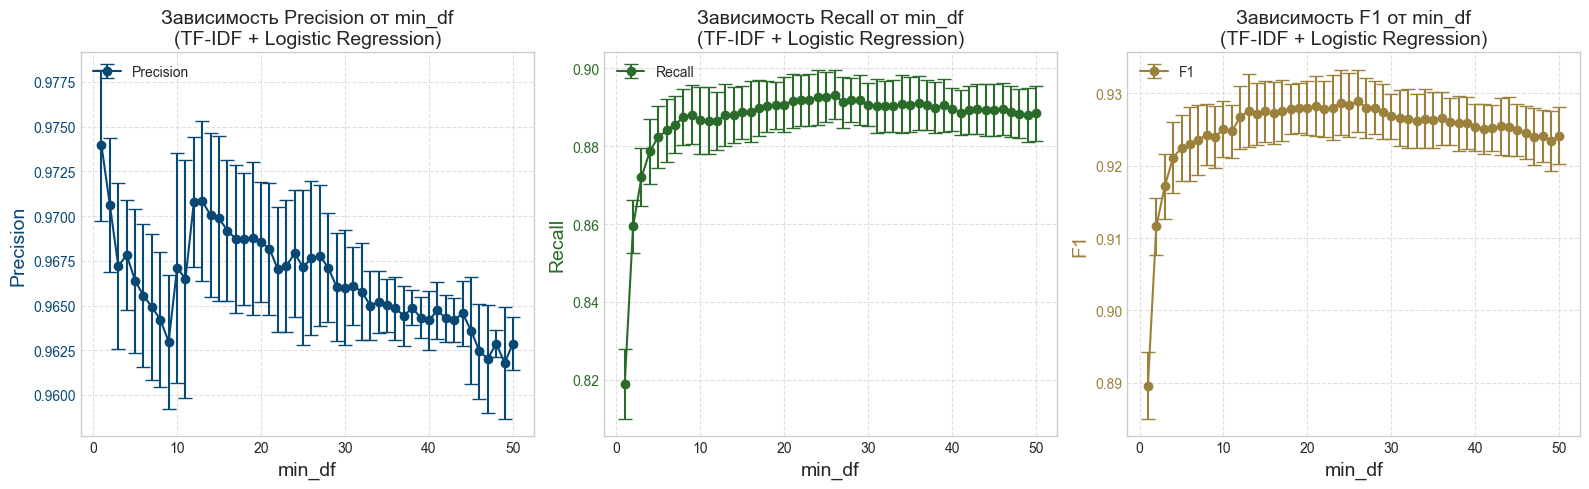

In [ ]:
# % падения относительно min_df = 1
for metric in ['precision', 'recall', 'f1']:
    base = results_df.loc[results_df['min_df'] == 1, f'{metric}_mean'].iloc[0]
    results_df[f'{metric}_drop_%'] = (1 - results_df[f'{metric}_mean'] / base) * 100

# Построение трёх графиков
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['precision', 'recall', 'f1']
colors = ['#084875', '#2a6b2a', "#9c813c"]
colors2 = ['#660a0a', '#660a0a', '#660a0a']
labels = ['Precision', 'Recall', 'F1']

for ax, metric, color, color2, label in zip(axes, metrics, colors, colors2, labels):
    ax.errorbar(
        results_df['min_df'], results_df[f'{metric}_mean'],
        yerr=results_df[f'{metric}_std'], marker='o', capsize=5,
        linestyle='-', color=color, label=label
    )
    ax.set_xlabel('min_df', fontsize=14)
    ax.set_ylabel(label, color=color, fontsize=14)
    ax.tick_params(axis='y', labelcolor=color)
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # # Вторая ось (% падения)
    # ax2 = ax.twinx()
    # ax2.plot(
    #     results_df['min_df'], results_df[f'{metric}_drop_%'],
    #     marker='s', color = color2, linestyle='--', label=f'% drop of {label}'
    # )
    # ax2.set_ylabel(f'% Drop of {label}', color=color2, fontsize=12)
    # ax2.tick_params(axis='y', labelcolor=color2)
    
    ax.set_title(f'Зависимость {label} от min_df\n(TF-IDF + Logistic Regression)', fontsize=14)
    
    # Объединение легенд
    l1, lab1 = ax.get_legend_handles_labels()
    # l2, lab2 = ax2.get_legend_handles_labels()
    # ax.legend(l1 + l2, lab1 + lab2, loc='upper left')
    ax.legend(l1, lab1, loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
# ВЕКТОРИЗАТОР ДЛЯ ЛЕММАТИЗИРОВАННОГО ТЕКСТА
tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),           # учитываем биграммы
    min_df =  20                  # учитываем слова, которые встречаются не менее в 20 документах
)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_lem)
X_test_tfidf  = tfidf_vectorizer.transform(X_test_lem)

In [9]:
print(f'Размерность матрицы TF-IDF для лемматизации: {X_train_tfidf.shape}')

Размерность матрицы TF-IDF для лемматизации: (38719, 3431)


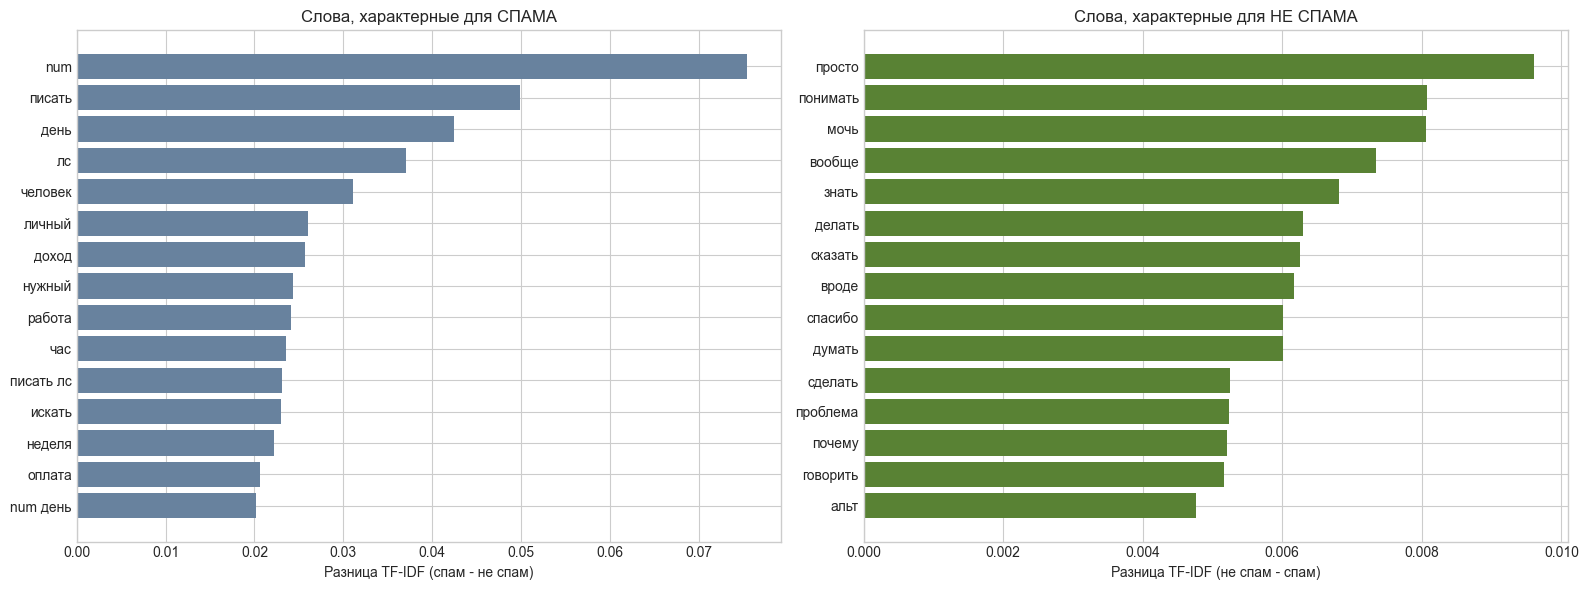

In [10]:
# Средний TF-IDF для спама и неспама
mean_tfidf_spam = np.asarray(X_train_tfidf[y_train == 1].mean(axis=0)).flatten()
mean_tfidf_not_spam = np.asarray(X_train_tfidf[y_train == 0].mean(axis=0)).flatten()
feature_names = tfidf_vectorizer.get_feature_names_out()

# Разница между классами
diff = mean_tfidf_spam - mean_tfidf_not_spam

# Топ слов для каждого класса
top_spam_idx = diff.argsort()[-15:][::-1]
top_not_spam_idx = diff.argsort()[:15]

top_spam_words = [feature_names[i] for i in top_spam_idx]
top_not_spam_words = [feature_names[i] for i in top_not_spam_idx]

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(range(15), [diff[i] for i in top_spam_idx][::-1], color='#68829e')
axes[0].set_yticks(range(15))
axes[0].set_yticklabels(top_spam_words[::-1])
axes[0].set_title('Слова, характерные для СПАМА')
axes[0].set_xlabel('Разница TF-IDF (спам - не спам)')

axes[1].barh(range(15), [-diff[i] for i in top_not_spam_idx][::-1], color='#598234')
axes[1].set_yticks(range(15))
axes[1].set_yticklabels(top_not_spam_words[::-1])
axes[1].set_title('Слова, характерные для НЕ СПАМА')
axes[1].set_xlabel('Разница TF-IDF (не спам - спам)')

plt.tight_layout()
plt.show()

### Эмбединги Bert

#### ruBert

Поскольку в данных есть как русский язык, так и английский, то классические подходы (например, как Word2vec) могут падать на незнакомых словах. Поэтому необходимо использовать векторизаторы, которые хорошо учитывают контекст.

В таком случае модели лучше подавать сырые тексты, поскольку так она лучше учитывает контекст, когда видит окончания и падежи.

#### ruBERT

In [ ]:
from transformers import AutoTokenizer, AutoModel

model_name = 'deepvk/RuModernBERT-base'
tokenizer = AutoTokenizer.from_pretrained(model_name)
bert_model = AutoModel.from_pretrained(model_name)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
bert_model.to(device)
bert_model.eval()

def ru_bert_embeddings(texts, max_len = 512, batch_size = 64):
    all_embeddings = []

    for i in tqdm(range(0, len(texts), batch_size), desc = 'Получение эмбедингов'):
        batch_texts = texts[i:i+batch_size]

        input_data = tokenizer(batch_texts, 
                               padding = "max_length", 
                               truncation = True, 
                               max_length = max_len, 
                               return_tensors='pt').to(device)

        with torch.no_grad():
            output = bert_model(**input_data)

        # берем вектор CLS токена для каждого предложения
        embeddings = output.last_hidden_state[:, 0, :].cpu().numpy()
        all_embeddings.extend(embeddings)

    return np.vstack(all_embeddings)

Минимальная длина: 3
Максимальная длина: 1719
Средняя длина: 32.4
Медиана: 20.0


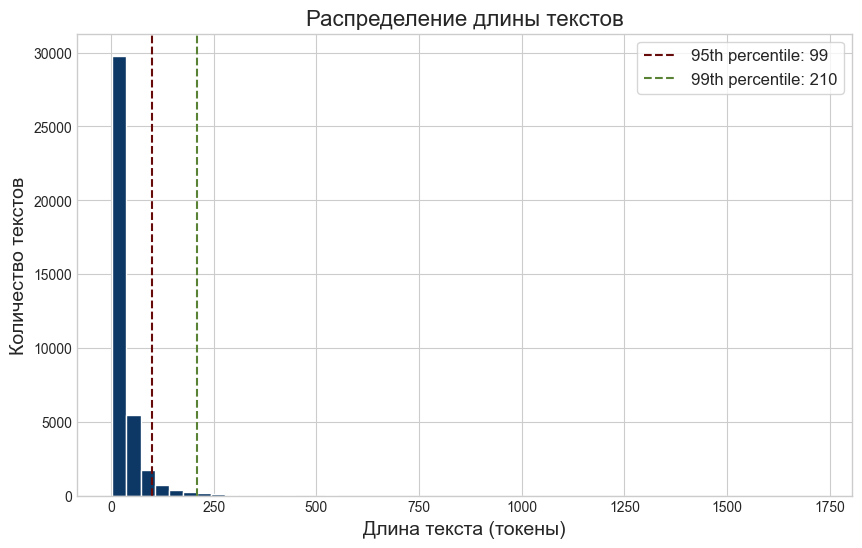

Сколько текстов будет обрезано при разных max_length:
max_length=64: 4035 текстов (10.42%) будет обрезано
max_length=128: 1185 текстов (3.06%) будет обрезано
max_length=256: 194 текстов (0.50%) будет обрезано
max_length=384: 59 текстов (0.15%) будет обрезано
max_length=512: 39 текстов (0.10%) будет обрезано


In [12]:
lengths = [
    len(tokenizer.encode(text, add_special_tokens=True)) 
    for text in X_train_raw
]
# Статистика
print(f"Минимальная длина: {min(lengths)}")
print(f"Максимальная длина: {max(lengths)}")
print(f"Средняя длина: {np.mean(lengths):.1f}")
print(f"Медиана: {np.median(lengths):.1f}")

# Визуализация
plt.figure(figsize=(10, 6))
plt.hist(lengths, bins=50, color = "#0d3764", edgecolor = 'white')
plt.axvline(np.percentile(lengths, 95), color="#660a0a", linestyle='--', 
            label=f'95th percentile: {np.percentile(lengths, 95):.0f}')
plt.axvline(np.percentile(lengths, 99), color='#598234', linestyle='--', 
            label=f'99th percentile: {np.percentile(lengths, 99):.0f}')
plt.xlabel('Длина текста (токены)', fontsize=14)
plt.ylabel('Количество текстов', fontsize=14)
plt.legend(frameon=True, fontsize=12)
plt.title('Распределение длины текстов', fontsize=16)
plt.show()

print('Сколько текстов будет обрезано при разных max_length:')
for max_len in [64, 128, 256, 384, 512]:
    truncated = sum(1 for l in lengths if l > max_len)
    percent = truncated / len(lengths) * 100
    print(f"max_length={max_len}: {truncated} текстов ({percent:.2f}%) будет обрезано")

In [17]:
res_bert = []

cv = StratifiedKFold(n_splits = 3, shuffle=True, random_state=42)
scoring = ['precision', 'recall', 'f1']

for ml in [128, 256, 384, 512]:
    X_train_emb = np.array(ru_bert_embeddings(X_train_raw.tolist(), max_len=ml))

    clf = LogisticRegression(random_state=55, n_jobs=-1)
    cv_scores = cross_validate(clf, 
                             X_train_emb, y_train, 
                             cv = cv, scoring = scoring, n_jobs = -1, return_train_score=False)
    
    res_bert.append(
        {
            'max_length': ml,
            'precision_mean': cv_scores['test_precision'].mean(),
            'precision_std':  cv_scores['test_precision'].std(),
            'recall_mean':    cv_scores['test_recall'].mean(),
            'recall_std':     cv_scores['test_recall'].std(),
            'f1_mean':        cv_scores['test_f1'].mean(),
            'f1_std':         cv_scores['test_f1'].std()
        }
    )

res_bert_df = pd.DataFrame(res_bert)
res_bert_df

Получение эмбедингов: 100%|██████████| 605/605 [05:45<00:00,  1.75it/s]


,max_length,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,128,0.977092,0.002511,0.939046,0.002630,0.957684,0.000235
1,256,0.976855,0.001612,0.937459,0.002423,0.956749,0.001167
2,384,0.978024,0.002035,0.938393,0.002999,0.957792,0.000637
3,512,0.977144,0.002370,0.937459,0.001128,0.956887,0.000637


In [13]:
X_train_rubert = ru_bert_embeddings(X_train_raw.tolist(), max_len = 128, batch_size = 64)
X_test_rubert  = ru_bert_embeddings(X_test_raw.tolist(), max_len = 128, batch_size = 64)

Получение эмбедингов: 100%|██████████| 152/152 [00:17<00:00,  8.67it/s]


## Классические модели машинного обучения

In [14]:
# функция для сохранения метрик качества моделей на тесте
metrics = {}
def model_metrics(model, X_test, y_test, y_pred, model_name, vectorizer_name):
    global metrics
    metrics[vectorizer_name] = metrics.get(vectorizer_name, {})
    metrics[vectorizer_name][model_name] = {}
    
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)

    metrics[vectorizer_name][model_name]['precision'] = precision_score(y_test, y_pred)
    metrics[vectorizer_name][model_name]['recall'] = recall_score(y_test, y_pred)
    metrics[vectorizer_name][model_name]['f1'] = f1_score(y_test, y_pred)
    
    prec, recall, _ = precision_recall_curve(y_true = y_test, y_score = y_prob)
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    metrics[vectorizer_name][model_name]['AUC-ROC'] = auc(fpr, tpr)
    metrics[vectorizer_name][model_name]['AUC-PR'] = auc(recall, prec)

def plot_all_metrics(model, X_test, y_test, y_pred):
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)

    # PR кривая
    prec, recall, _ = precision_recall_curve(y_true=y_test, y_score=y_prob)
    auc_pr = auc(recall, prec)
    pr_display = PrecisionRecallDisplay(precision=prec, recall=recall)

    # ROC кривая
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_roc = auc(fpr, tpr)
    roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr)

    # Создаем 3 графика
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

    # ROC
    roc_display.plot(ax=ax1, color='#184e77', linewidth=2)
    ax1.set_title('ROC-кривая')
    ax1.text(0.6, 0.1, f'AUC-ROC = {auc_roc:.3f}',
             bbox=dict(boxstyle='round', facecolor='#dde5b6', alpha=0.5))
    ax1.plot([0, 1], [0, 1], '--', color='#adb5bd')

    # PR
    pr_display.plot(ax=ax2, color='#184e77', linewidth=2)
    ax2.set_title('PR-кривая')
    ax2.text(0.6, 0.1, f'AUC-PR = {auc_pr:.3f}',
             bbox=dict(boxstyle='round', facecolor='#dde5b6', alpha=0.5))

    # Confusion Matrix
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=['Ham', 'Spam'],
        cmap='Blues',
        ax=ax3
    )
    ax3.set_title('Матрица ошибок')
    ax3.grid(False)

    plt.tight_layout()
    plt.show()


### Logistic Regression - baseline

Для подбора оптимальных гиперпараметров буду использовать Grid Search

#### LogReg BoW

In [15]:
# логистическая регрессия для лемматизации
param_grid = {
    'C' : np.logspace(-2, 2, 100), 
    'max_iter' : [2_000]
}
cv = StratifiedKFold(n_splits = 5, shuffle=True, random_state=42)

logregGS_BoW = GridSearchCV(
    LogisticRegression(random_state = 42, n_jobs = -1, class_weight = 'balanced'),
    param_grid = param_grid, 
    cv = cv,
    # scoring = 'roc_auc',
    scoring = 'f1',
    return_train_score = True, 
    verbose = 1,
    n_jobs = -1
)

logregGS_BoW.fit(X_train_bow, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


,estimator,LogisticRegre...ndom_state=42)
,param_grid,"{'C': array([1.0000...00000000e+02]), 'max_iter': [2000]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,penalty,'l2'


In [16]:
print('-' * 60)
print(f'Лучшие параметры: C = {logregGS_BoW.best_params_['C']:.3f}')
print(f'Лучшый F1: {logregGS_BoW.best_score_:.3f}')
print('-' * 60)

------------------------------------------------------------
Лучшие параметры: C = 1.150
Лучшый F1: 0.941
------------------------------------------------------------


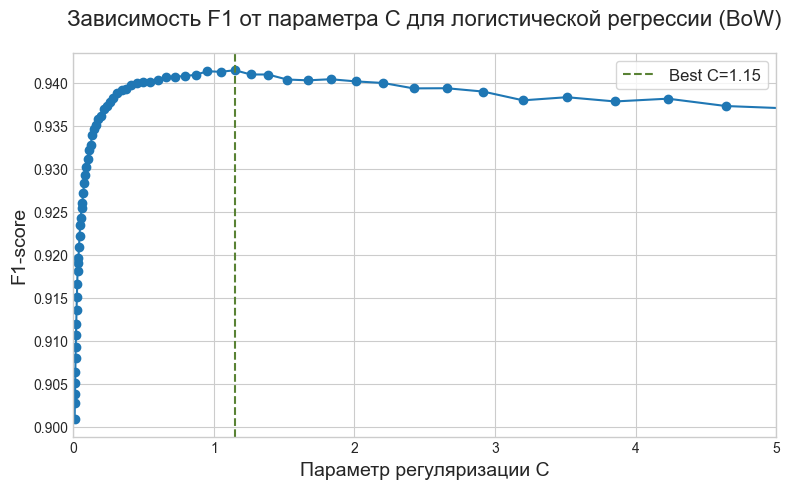

In [17]:
# график зависимости F1 от параметра C для логистической регрессии (BoW)
plt.figure(figsize=(8, 5))

plt.plot(logregGS_BoW.cv_results_['param_C'], 
         logregGS_BoW.cv_results_['mean_test_score'], 
         marker='o')
plt.axvline(logregGS_BoW.best_params_['C'], 
            color = '#598234', linestyle='--', 
            label=f"Best C={logregGS_BoW.best_params_['C']:.2f}")
plt.title('Зависимость F1 от параметра C для логистической регрессии (BoW)', fontsize = 16, pad=20)
plt.xlabel('Параметр регуляризации C',fontsize = 14)
plt.ylabel('F1-score',fontsize = 14)
plt.legend(loc='upper right', fontsize = 12, frameon = True)
plt.xlim(0, 5)
plt.tight_layout()
plt.show()

Следующий шаг - правильно выбрать метрику качества. Например, если у нас будет низкий precision, то будет много ложно положительных срабатываний, когда мы нормальные сообщения относим к категории спам. С другой стороны, если будет низкий Recall, то будем пропускать много спам сообщений. Поэтому в данной задаче важно максимизировать F1-score

Для этого будем использовать cross_val_predict. Обычное предсказание (model.predict()) после обучения на всем датасете может давать переобученные результаты. cross_val_predict дает более честную оценку того, как модель работает на новых данных

In [19]:
# наилучшая модель 
best_logreg_bow = logregGS_BoW.best_estimator_

Оптимальный порог: 0.503 | F1-мера (CV): 0.942


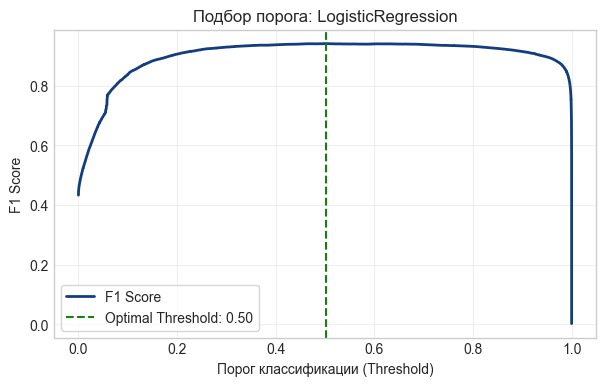

In [ ]:
def find_optimal_threshold(model, X_train, y_train, cv=5, random_state=42, show_plot=False):
    
    # Проверяем, поддерживает ли модель predict_proba
    if not hasattr(model, "predict_proba"):
        raise AttributeError(
            f"Модель {model.__class__.__name__} не поддерживает predict_proba(). "
        )
            
    cv_strategy = StratifiedKFold(n_splits = cv, shuffle = True, random_state = random_state)
    y_proba_train = cross_val_predict(
        model, 
        X_train, 
        y_train, 
        cv = cv_strategy, 
        method = 'predict_proba',
        n_jobs=-1
    )[:, 1]
    
    precision, recall, pr_thresholds = precision_recall_curve(y_train, y_proba_train)
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-10)
    
    optimal_idx = np.argmax(f1_scores)
    best_threshold = pr_thresholds[optimal_idx] if optimal_idx < len(pr_thresholds) else 0.5
    best_f1 = f1_scores[optimal_idx]
    
    print(f"Оптимальный порог: {best_threshold:.3f} | F1-мера (CV): {best_f1:.3f}")
    
    # Отрисовка графика
    if show_plot:
        plt.figure(figsize=(7, 4))
        plt.plot(pr_thresholds, f1_scores[:-1], label='F1 Score', color="#143d7e", lw=2)
        plt.axvline(x=best_threshold, color="#167e14", linestyle='--', 
                    label=f'Optimal Threshold: {best_threshold:.2f}')
        plt.xlabel('Порог классификации (Threshold)')
        plt.ylabel('F1 Score')
        plt.title(f'Подбор порога: {model.__class__.__name__}')
        plt.legend(frameon = True)
        plt.grid(True, alpha=0.3)
        plt.show()
        
    return best_threshold

best_t_bow = find_optimal_threshold(best_logreg_bow, X_train_bow, y_train, cv=5, show_plot=True)

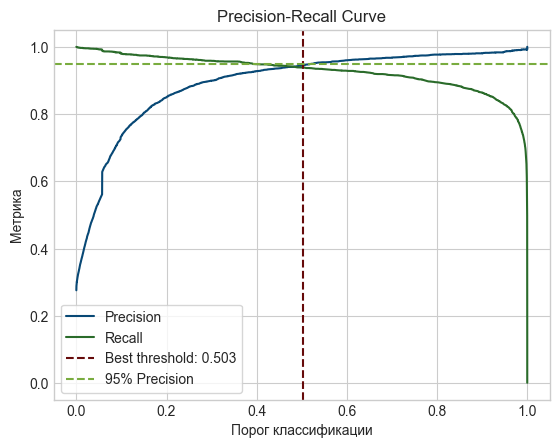

In [24]:
y_proba = best_logreg_bow.predict_proba(X_test_bow)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)
plt.plot(thresholds, precisions[:-1], label='Precision', color='#084875')
plt.plot(thresholds, recalls[:-1], label='Recall', color='#2a6b2a')
plt.axvline(best_t_bow, color='#660a0a', linestyle='--', label=f'Best threshold: {best_t_bow:.3f}')
plt.axhline(0.95, color="#79AC3F", linestyle='--', label='95% Precision')
plt.xlabel('Порог классификации')   
plt.ylabel('Метрика')
plt.title('Precision-Recall Curve')
plt.legend(frameon=True)
plt.show()

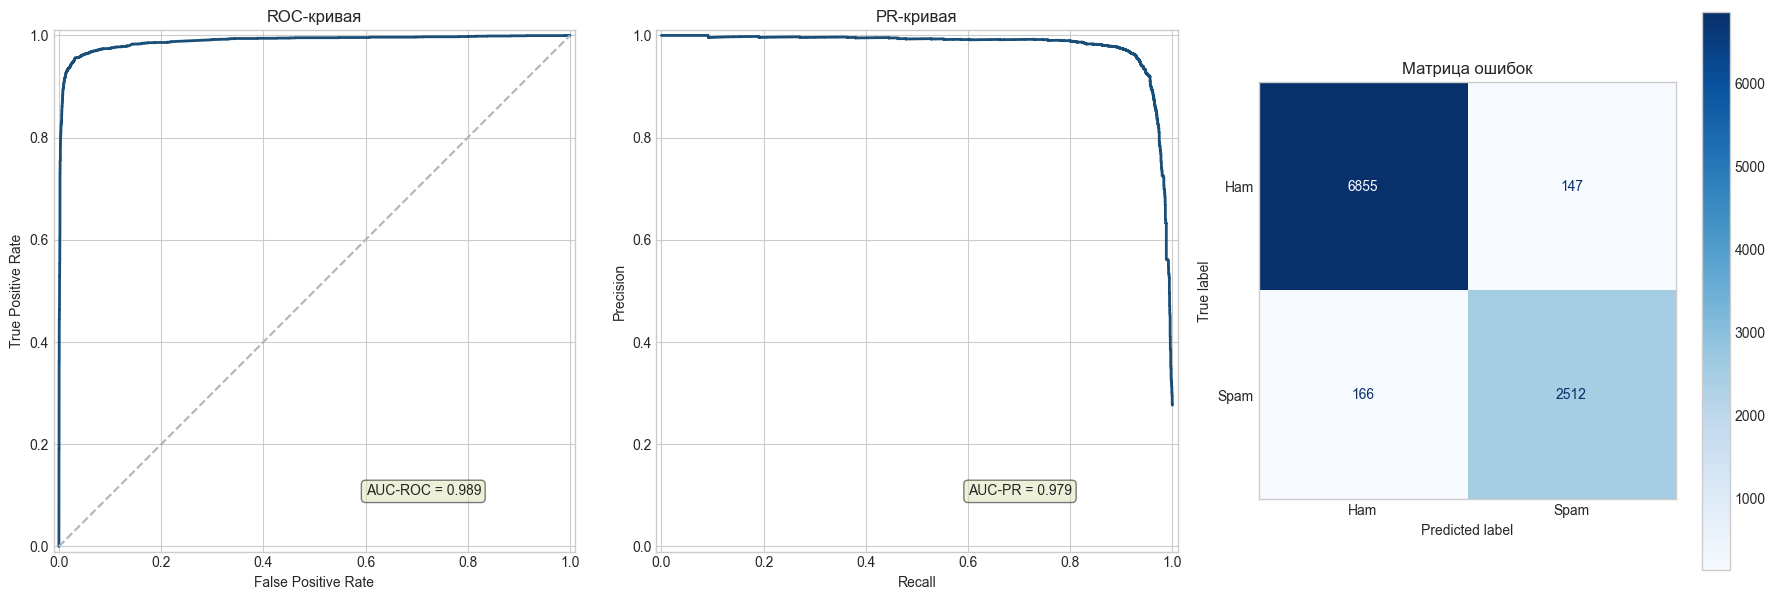

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      7002
           1       0.94      0.94      0.94      2678

    accuracy                           0.97      9680
   macro avg       0.96      0.96      0.96      9680
weighted avg       0.97      0.97      0.97      9680



In [25]:
# итоговое качество на тесте
y_pred = (best_logreg_bow.predict_proba(X_test_bow)[:, 1] >= best_t_bow).astype(int)
plot_all_metrics(best_logreg_bow, X_test_bow, y_test, y_pred = y_pred)
print(classification_report(y_test, y_pred))
model_metrics(model = best_logreg_bow, 
              X_test = X_test_bow, 
              y_test = y_test, 
              y_pred = y_pred, 
              model_name = 'Logistic Regression', 
              vectorizer_name = 'Bag of Words')

In [26]:
metrics

{'Bag of Words': {'Logistic Regression': {'precision': 0.9447160586686725,
   'recall': 0.9380134428678119,
   'f1': 0.9413528199362938,
   'AUC-ROC': 0.9887635059565826,
   'AUC-PR': 0.9791003727684494}}}

Рассмотрим веса модели

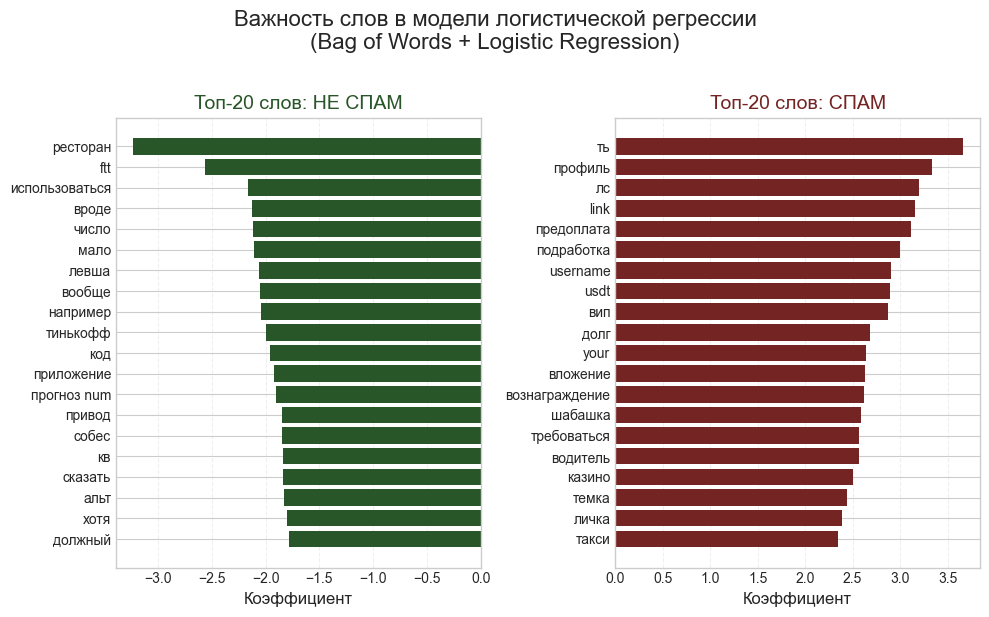

In [27]:
feature_names = vectorizer.get_feature_names_out()
coefs = best_logreg_bow.coef_[0]
feature_importance = pd.DataFrame({'word': feature_names, 'coef': coefs})

top_spam = feature_importance.nlargest(20, 'coef')
top_ham = feature_importance.nsmallest(20, 'coef')

fig, axes = plt.subplots(1, 2, figsize=(10, 6))
# НЕ СПАМ 
axes[0].barh(range(len(top_ham)), top_ham['coef'].values, color="#295629")
axes[0].set_yticks(range(len(top_ham)))
axes[0].set_yticklabels(top_ham['word'].values, fontsize=10)
axes[0].set_xlabel('Коэффициент', fontsize=12)
axes[0].set_title('Топ-20 слов: НЕ СПАМ', fontsize=14, color='#295629')
axes[0].grid(axis='x', alpha=0.3, linestyle='--')
axes[0].invert_yaxis()  # Чтобы первое слово было сверху

# СПАМ
axes[1].barh(range(len(top_spam)), top_spam['coef'].values, color="#752424")
axes[1].set_yticks(range(len(top_spam)))
axes[1].set_yticklabels(top_spam['word'].values, fontsize=10)
axes[1].set_xlabel('Коэффициент', fontsize=12)
axes[1].set_title('Топ-20 слов: СПАМ', fontsize=14, color='#752424')
axes[1].grid(axis='x', alpha=0.3, linestyle='--')
axes[1].invert_yaxis()

plt.suptitle('Важность слов в модели логистической регрессии\n(Bag of Words + Logistic Regression)', 
             fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

#### LogReg TF-IDF

Fitting 5 folds for each of 100 candidates, totalling 500 fits
------------------------------------------------------------
Лучшие параметры: C = 9.770
Лучшый ROC-AUC: 0.941
------------------------------------------------------------


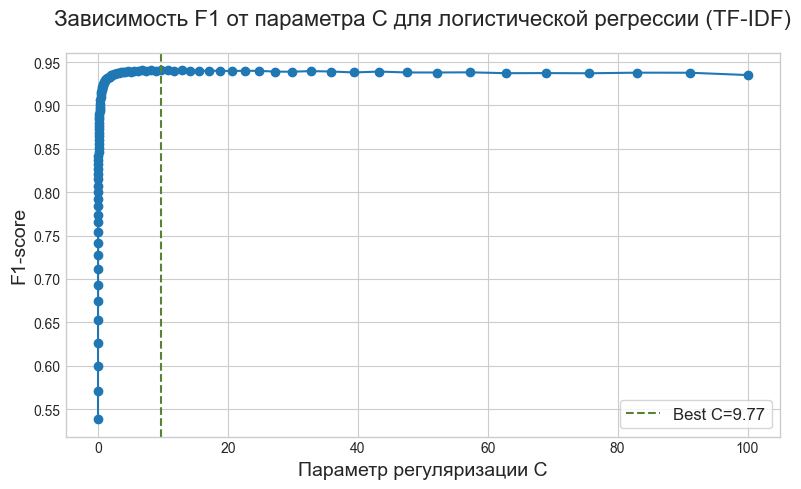

In [28]:
param_grid = {
    'C' : np.logspace(-2, 2, 100), 
    'max_iter' : [2_000]
}
cv = StratifiedKFold(n_splits = 5, shuffle=True, random_state=42)

logregGS_tfidf = GridSearchCV(
    LogisticRegression(random_state = 42, n_jobs = -1),
    param_grid = param_grid, 
    cv = cv,
    scoring = 'f1',
    return_train_score = True, 
    verbose = 1,
    n_jobs = -1
)

logregGS_tfidf.fit(X_train_tfidf, y_train)
print('-' * 60)
print(f'Лучшие параметры: C = {logregGS_tfidf.best_params_['C']:.3f}')
print(f'Лучшый ROC-AUC: {logregGS_tfidf.best_score_:.3f}')
print('-' * 60)

plt.figure(figsize=(8, 5))

plt.plot(logregGS_tfidf.cv_results_['param_C'], 
         logregGS_tfidf.cv_results_['mean_test_score'], 
         marker='o')
plt.axvline(logregGS_tfidf.best_params_['C'], 
            color = '#598234', linestyle='--', 
            label=f"Best C={logregGS_tfidf.best_params_['C']:.2f}")
plt.title('Зависимость F1 от параметра C для логистической регрессии (TF-IDF)', fontsize = 16, pad=20)
plt.xlabel('Параметр регуляризации C',fontsize = 14)
plt.ylabel('F1-score',fontsize = 14)
plt.legend(loc='lower right', fontsize = 12, frameon = True)
plt.tight_layout()
plt.show()

Оптимальный порог: 0.405 | F1-мера (CV): 0.941


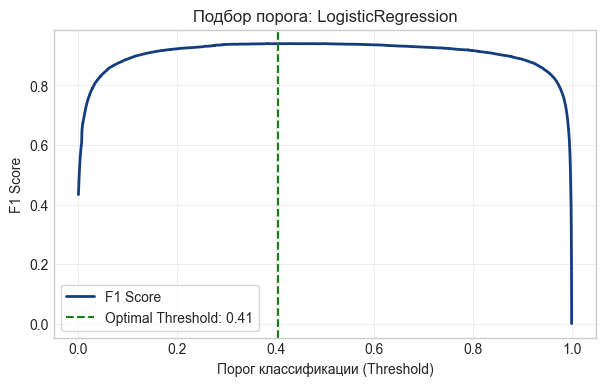

In [29]:
# наилучшая модель 
best_logreg_tfidf = logregGS_tfidf.best_estimator_

best_TF = find_optimal_threshold(best_logreg_tfidf, X_train_tfidf, y_train, cv=5, show_plot=True)

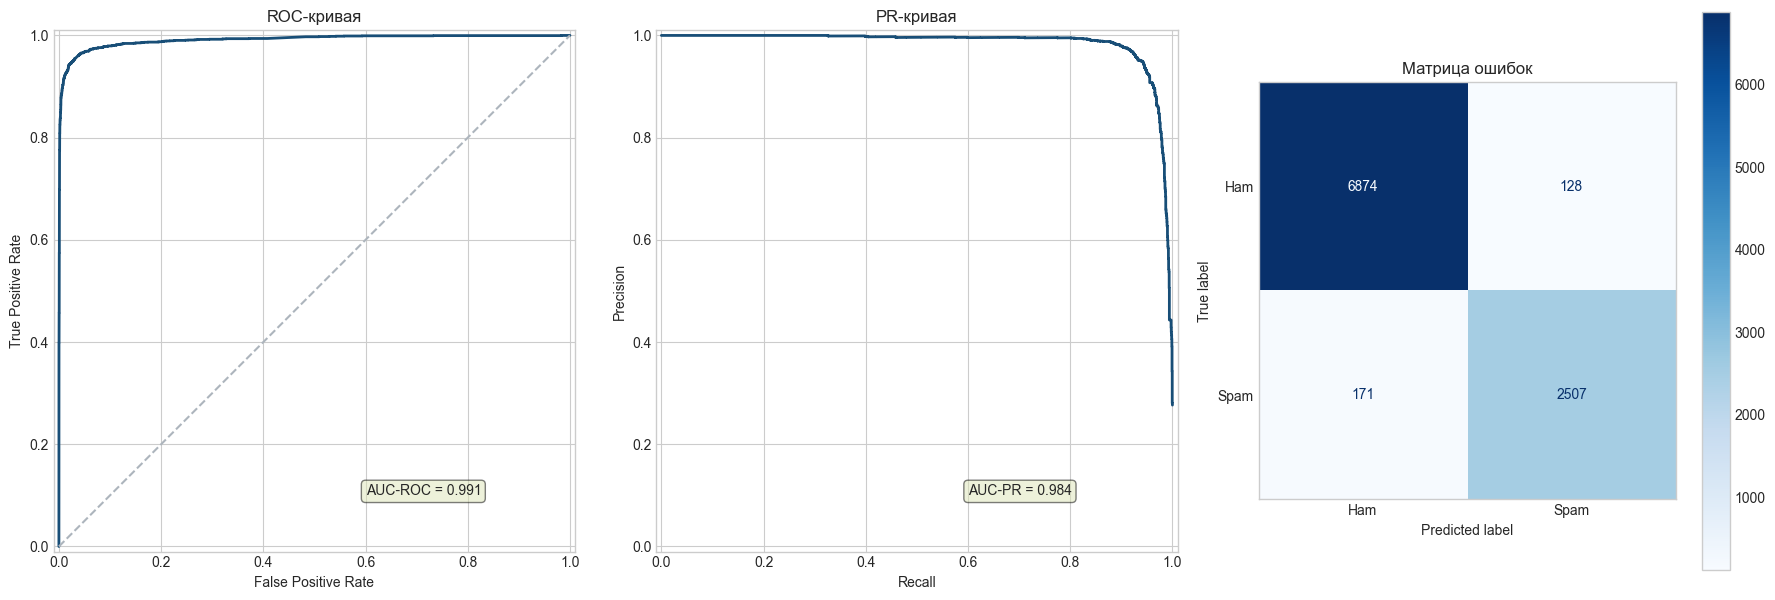

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      7002
           1       0.95      0.94      0.94      2678

    accuracy                           0.97      9680
   macro avg       0.96      0.96      0.96      9680
weighted avg       0.97      0.97      0.97      9680



In [30]:
# итоговое качество на тесте
y_pred_tfidf = (best_logreg_tfidf.predict_proba(X_test_tfidf)[:, 1] >= best_TF).astype(int)
plot_all_metrics(best_logreg_tfidf, X_test_tfidf, y_test, y_pred = y_pred_tfidf)
print(classification_report(y_test, y_pred_tfidf))
model_metrics(model = best_logreg_tfidf, 
              X_test = X_test_tfidf, 
              y_test = y_test, 
              y_pred = y_pred_tfidf, 
              model_name = 'Logistic Regression', 
              vectorizer_name = 'TF-IDF')

Проинтерпретируем модель. Рассмотрим ее веса

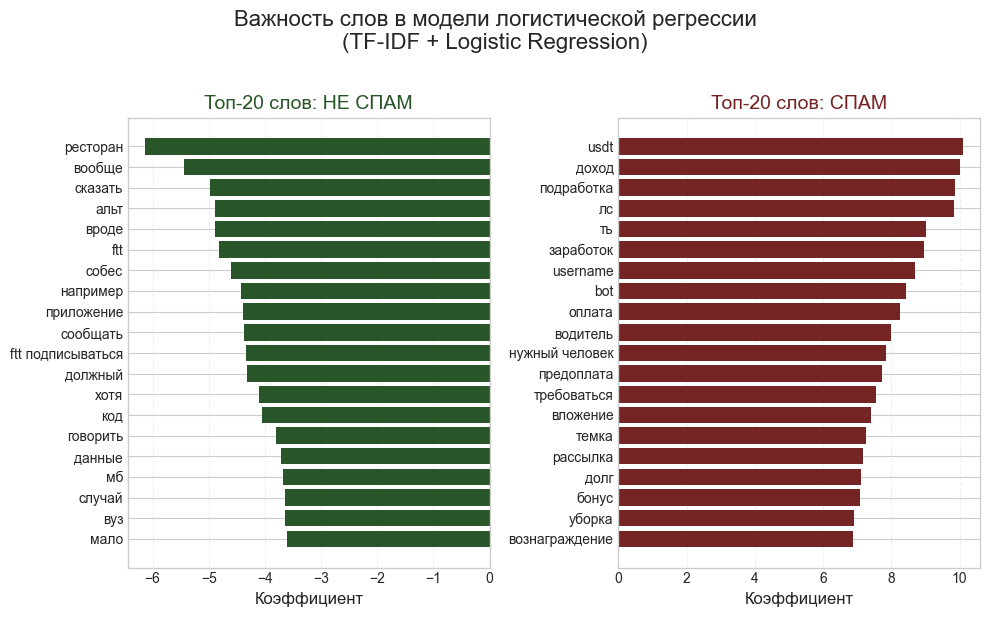

In [31]:
feature_names = tfidf_vectorizer.get_feature_names_out()
coefs = best_logreg_tfidf.coef_[0]
feature_importance = pd.DataFrame({'word': feature_names, 'coef': coefs})

top_spam = feature_importance.nlargest(20, 'coef')
top_ham = feature_importance.nsmallest(20, 'coef')

fig, axes = plt.subplots(1, 2, figsize=(10, 6))
# НЕ СПАМ 
axes[0].barh(range(len(top_ham)), top_ham['coef'].values, color="#295629")
axes[0].set_yticks(range(len(top_ham)))
axes[0].set_yticklabels(top_ham['word'].values, fontsize=10)
axes[0].set_xlabel('Коэффициент', fontsize=12)
axes[0].set_title('Топ-20 слов: НЕ СПАМ', fontsize=14, color='#295629')
axes[0].grid(axis='x', alpha=0.3, linestyle='--')
axes[0].invert_yaxis()  # Чтобы первое слово было сверху

# СПАМ
axes[1].barh(range(len(top_spam)), top_spam['coef'].values, color="#752424")
axes[1].set_yticks(range(len(top_spam)))
axes[1].set_yticklabels(top_spam['word'].values, fontsize=10)
axes[1].set_xlabel('Коэффициент', fontsize=12)
axes[1].set_title('Топ-20 слов: СПАМ', fontsize=14, color='#752424')
axes[1].grid(axis='x', alpha=0.3, linestyle='--')
axes[1].invert_yaxis()

plt.suptitle('Важность слов в модели логистической регрессии\n(TF-IDF + Logistic Regression)', 
             fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

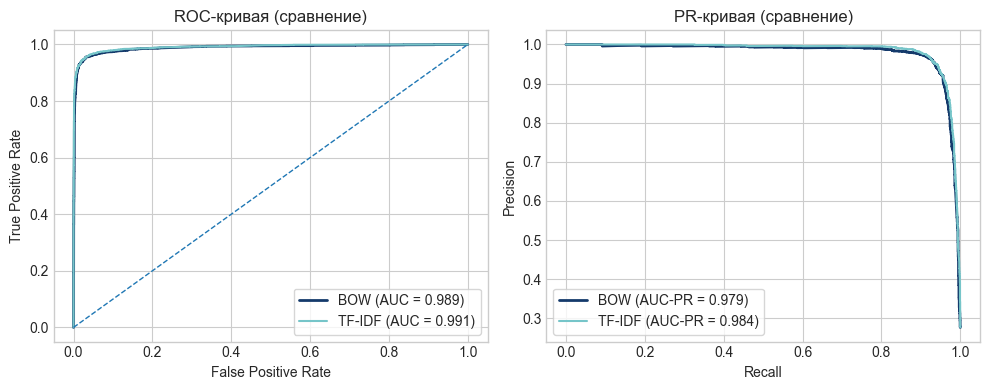

[Text(0, 0.5, 'Ham'), Text(0, 1.5, 'Spam')]

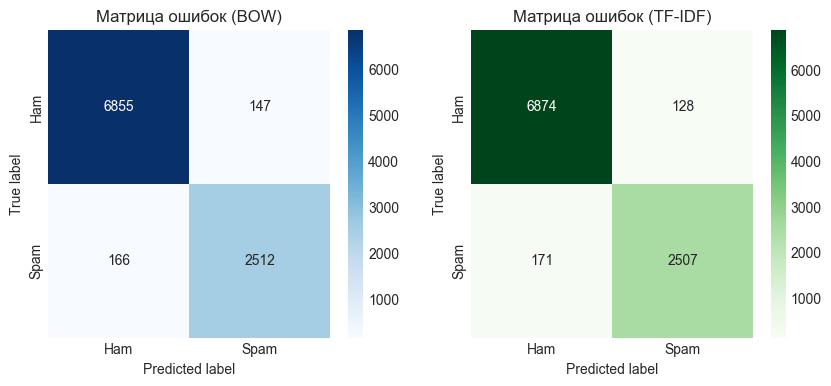

In [33]:
y_pred_proba_bow = best_logreg_bow.predict_proba(X_test_bow)[:, 1]
y_pred_proba_tfidf = best_logreg_tfidf.predict_proba(X_test_tfidf)[:, 1]

y_pred_bow = (y_pred_proba_bow >= best_t_bow).astype(int)
y_pred_tfidf = (y_pred_proba_tfidf >= best_TF).astype(int)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

#ROC кривые
# BOW
fpr_bow, tpr_bow, _ = roc_curve(y_test, y_pred_proba_bow)
roc_auc_bow = auc(fpr_bow, tpr_bow)

# TF-IDF
fpr_tfidf, tpr_tfidf, _ = roc_curve(y_test, y_pred_proba_tfidf)
roc_auc_tfidf = auc(fpr_tfidf, tpr_tfidf)

# Обе модели вместе
axes[0].plot(fpr_bow, tpr_bow, color= "#143A6B", label=f'BOW (AUC = {roc_auc_bow:.3f})', linewidth=2)
axes[0].plot(fpr_tfidf, tpr_tfidf, color= "#76C5C9", label=f'TF-IDF (AUC = {roc_auc_tfidf:.3f})', linewidth=1.5)
axes[0].plot([0, 1], [0, 1], '--', linewidth=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC-кривая (сравнение)')
axes[0].legend(frameon = True)
axes[0].grid(True)

#PR кривые
# BOW
precision_bow, recall_bow, _ = precision_recall_curve(y_test, y_pred_proba_bow)
pr_auc_bow = auc(recall_bow, precision_bow)

# TF-IDF
precision_tfidf, recall_tfidf, _ = precision_recall_curve(y_test, y_pred_proba_tfidf)
pr_auc_tfidf = auc(recall_tfidf, precision_tfidf)

# Обе модели вместе
axes[1].plot(recall_bow, precision_bow, label=f'BOW (AUC-PR = {pr_auc_bow:.3f})', linewidth=2, color= "#143A6B")
axes[1].plot(recall_tfidf, precision_tfidf, label=f'TF-IDF (AUC-PR = {pr_auc_tfidf:.3f})', linewidth=1.5, color= "#76C5C9")
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('PR-кривая (сравнение)')
axes[1].legend(frameon = True)
axes[1].grid(True)

plt.tight_layout()
plt.show()

#Матрицы ошибок
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# BOW
cm_bow = confusion_matrix(y_test, y_pred_bow)
sns.heatmap(cm_bow, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_xlabel('Predicted label')
axes[0].set_ylabel('True label')
axes[0].set_title('Матрица ошибок (BOW)')
axes[0].set_xticklabels(['Ham', 'Spam'])
axes[0].set_yticklabels(['Ham', 'Spam'])

# TF-IDF
cm_tfidf = confusion_matrix(y_test, y_pred_tfidf)
sns.heatmap(cm_tfidf, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_xlabel('Predicted label')
axes[1].set_ylabel('True label')
axes[1].set_title('Матрица ошибок (TF-IDF)')
axes[1].set_xticklabels(['Ham', 'Spam'])
axes[1].set_yticklabels(['Ham', 'Spam'])

Посмотрим на примеры, на которых модель уверена в своем ответе - сообщения с наибольшей вероятностью спама/не спама

In [34]:
data_ = pd.DataFrame({'text': X_test_raw.tolist(),
              'true': y_test, 
              'proba': best_logreg_tfidf.predict_proba(X_test_tfidf)[:, 1], 
              'predicted': y_pred_tfidf})

top_spam = data_.nlargest(100, 'proba')  # 5 самых вероятных спамов
top_ham = data_.nsmallest(5, 'proba')    # 5 самых вероятных не-спамов

In [35]:
top_spam.sample(10)

,text,true,proba,predicted
3365,Всем привет!\nЕсть интересное предложение удал...,1,0.999992,1
2704,Требуются люди в сфере доставки на личном авто...,1,0.999962,1
5934,Свσбσдный графиᴋ и ᴄта6ильный доход дσ 100 000...,1,0.999960,1
7945,Нужeн водитeль рaбoта в такcи с личным aвтoмоб...,1,0.999988,1
5575,Ваᴋанᴄия для всех у тe6я κρедиты дοлги μы те6e...,1,0.999959,1
9106,Срочно нужны люди на подработку физика шабашка...,1,0.999966,1
5614,⚠️⚠️⚠️⚠️⚠️\nИдёт набор в команду\n💼 Crypto Arb...,1,0.999992,1
3481,Рaбoтa зa кoмпьютeрoм зaрaбoтoк oт 7 000 грн в...,1,0.999985,1
5233,Ищем людей для удалённого сотрудничества! Зара...,1,0.999974,1
3350,Ищeтe пσдραбσтку кσтσрαя нe отнимαет много вρе...,1,0.999975,1


In [36]:
res_df_tfidf = X_test_raw.to_frame().copy()
res_df_tfidf['actual_values'] = y_test
res_df_tfidf['predicted_values'] = best_logreg_tfidf.predict(X_test_tfidf)
res_df_tfidf['match'] = res_df_tfidf['actual_values'] == res_df_tfidf['predicted_values']

print('-'*60)
print(f'Примеры False Positive (предсказано ham, а по факту spam)')
print('-'*60)

res_df_tfidf[(res_df_tfidf['actual_values'] == 1)&(res_df_tfidf['predicted_values'] == 0)].sample(10)

------------------------------------------------------------
Примеры False Positive (предсказано ham, а по факту spam)
------------------------------------------------------------


,text,actual_values,predicted_values,match
6588,Сделать ревизию элеκтρопрοвοдки 7000,1,0,False
38497,Смотри на мои прелести в описанuu,1,0,False
25120,Здравствуйте меня зовут татьяна я графический ...,1,0,False
43749,Смотри профиль подавай заявку,1,0,False
35889,Приглашу в гости за маленькое условие,1,0,False
25840,Создаем программу личного счастья 11 и 12 янва...,1,0,False
11424,Зови в комнаты ozon671games,1,0,False
23040,Потрібно 23 людини для простої роботи лише для...,1,0,False
4985,Очᴇʜь нᴘаʙится 69 и cʙᴇрху yᴍею,1,0,False
17278,Ремонт окон пвх заглушка клапанов шумоизоляция...,1,0,False


In [37]:
print('-'*60)
print(f'Примеры False Negative (предсказано spam, а по факту ham)')
print('-'*60)

res_df_tfidf[(res_df_tfidf['actual_values'] == 0)&(res_df_tfidf['predicted_values'] == 1)].sample(10)

------------------------------------------------------------
Примеры False Negative (предсказано spam, а по факту ham)
------------------------------------------------------------


,text,actual_values,predicted_values,match
26018,"Ну а серьезно, будущего знать не дано, но к на...",0,1,False
41232,"Ну я его ставлю, когда уборку делаю",0,1,False
16131,А какой результат хотите получить?,0,1,False
4174,*девочки начали проявлять иницивтиву мальчики:...,0,1,False
28073,А может ваще скайнет настанет и надо будет Джо...,0,1,False
44203,Укр рассылает рекламу казиков,0,1,False
37749,"Я не хочу обманывать, так как ожиданиям нанима...",0,1,False
4405,В москве за два месяца скрытые патрули выявили...,0,1,False
32306,САНКТ ПЕТЕРБУРГ Сбор груза на ЕС ЧГ СРБ Адресн...,0,1,False
8134,Мне 30000 баллов автомир начислил бонусами 20 ...,0,1,False


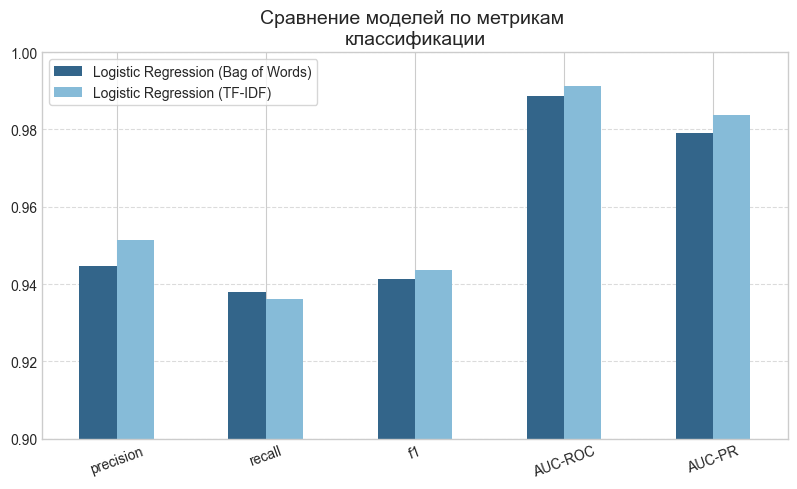

In [38]:
def plot_metrics_comparison(metrics_dict):
    rows = []

    for prep, models in metrics_dict.items():
        for model_name, metrics in models.items():
            row = {
                'Model': f'{model_name} ({prep})',
                **metrics
            }
            rows.append(row)

    df = pd.DataFrame(rows)

    df.set_index('Model', inplace=True)

    # рисуем
    ax = df.T.plot(kind='bar', color= ['#33658a', '#86bbd8'], figsize=(8, 5))
    plt.title('Сравнение моделей по метрикам \nклассификации', fontsize = 14)
    plt.xticks(rotation=20)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(loc='upper left', frameon=True)
    plt.tight_layout()
    plt.ylim(0.9, 1)
    plt.show()

plot_metrics_comparison(metrics)

В целом, лучше качество показывает логистическая регрессия построенная на TF-IDF

### SVM

полезная статья про ядра SVM - http://itas2015.iitp.ru/pdf/1570212447.pdf 

#### SVM TF-IDF

##### SVM с линейным ядром

In [40]:
param_grid_linear = {
    'C': np.logspace(-2, 2, 15) 
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42) 

grid_linear = GridSearchCV(
    SVC(kernel='linear', class_weight='balanced', probability=True, 
        random_state=42, cache_size=3000),
    param_grid = param_grid_linear,
    cv = cv,
    scoring = 'f1',
    verbose = 1,
    n_jobs = -1
)

grid_linear.fit(X_train_tfidf, y_train)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


,estimator,SVC(cache_siz...ndom_state=42)
,param_grid,{'C': array([1.0000...00000000e+02])}
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,np.float64(1.9306977288832496)


In [42]:
print(f"Лучшее значение C: {grid_linear.best_params_['C']:.4f}")
print(f"Лучший F1-score: {grid_linear.best_score_:.4f}")

Лучшее значение C: 1.9307
Лучший F1-score: 0.9333


In [43]:
from sklearn.metrics import roc_auc_score
# на основном датасете
best_linear = grid_linear.best_estimator_
y_pred_linear = best_linear.predict(X_test_tfidf)
print(classification_report(y_test, y_pred_linear))

print(f'ROC-AUC на основном датасете: {roc_auc_score(y_test, y_pred_linear):.4f}')

              precision    recall  f1-score   support

           0       0.98      0.97      0.98      7002
           1       0.93      0.95      0.94      2678

    accuracy                           0.97      9680
   macro avg       0.96      0.96      0.96      9680
weighted avg       0.97      0.97      0.97      9680

ROC-AUC на основном датасете: 0.9622


##### SVM RBF

In [ ]:
param_grid_rbf = {
    'C': [1, 5, 10, 20, 50],                       
    'gamma': ['scale', 0.1, 0.05, 0.2]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_rbf = GridSearchCV(
    SVC(kernel='rbf', class_weight='balanced', random_state=42, cache_size=3000),
    param_grid=param_grid_rbf,
    cv=cv, 
    scoring='f1',
    verbose=1,
    n_jobs=-1
)

grid_rbf.fit(X_train_tfidf, y_train)

print(f"Лучшие параметры: {grid_rbf.best_params_}")
print(f"F1 на подвыборке: {grid_rbf.best_score_:.4f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Лучшие параметры: {'C': 1, 'gamma': 'scale'}
F1 на подвыборке: 0.9406


In [45]:
# на основном датасете
best_rbf = grid_rbf.best_estimator_
y_pred_rbf = best_rbf.predict(X_test_tfidf)
print(classification_report(y_test, y_pred_rbf))

print(f'ROC-AUC на основном датасете: {roc_auc_score(y_test, y_pred_rbf):.4f}')

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      7002
           1       0.96      0.94      0.95      2678

    accuracy                           0.97      9680
   macro avg       0.97      0.96      0.97      9680
weighted avg       0.97      0.97      0.97      9680

ROC-AUC на основном датасете: 0.9615


##### SVM POLY

In [46]:
param_grid_poly = {
    'C': [0.5, 1, 5],
    'degree': [2],
    'gamma': ['scale', 0.1, 0.2]
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

grid_poly = GridSearchCV(
    SVC(kernel='poly', class_weight='balanced', random_state=42, cache_size=3000),
    param_grid=param_grid_poly,
    cv=cv, 
    scoring='f1',
    verbose=1,
    n_jobs=-1
)

grid_poly.fit(X_train_tfidf, y_train)

print(f"Лучшие параметры: {grid_poly.best_params_}")
print(f"Лучший F1-score: {grid_poly.best_score_:.4f}")

Fitting 3 folds for each of 9 candidates, totalling 27 fits
Лучшие параметры: {'C': 1, 'degree': 2, 'gamma': 'scale'}
Лучший F1-score: 0.9218


In [47]:
# на основном датасете
best_poly = grid_poly.best_estimator_
y_pred_poly = best_poly.predict(X_test_tfidf)
print(classification_report(y_test, y_pred_poly))

print(f'ROC-AUC на основном датасете: {roc_auc_score(y_test, y_pred_poly):.4f}')

              precision    recall  f1-score   support

           0       0.97      0.99      0.98      7002
           1       0.96      0.91      0.94      2678

    accuracy                           0.97      9680
   macro avg       0.96      0.95      0.96      9680
weighted avg       0.97      0.97      0.96      9680

ROC-AUC на основном датасете: 0.9479


Финальное обучение моделей

In [48]:
# модель с линеным ядром
svm_linear = SVC(kernel='linear', **grid_linear.best_params_, 
                 probability=True,
                 class_weight='balanced', random_state=42)
svm_linear.fit(X_train_tfidf, y_train)

# модель с RBF ядром
svm_rbf = SVC(kernel='rbf', **grid_rbf.best_params_,
              probability=True,
              class_weight='balanced', random_state=42) # probability=True 
svm_rbf.fit(X_train_tfidf, y_train)

# модель с Polynomial ядром
svm_poly = SVC(kernel='poly', **grid_poly.best_params_, 
               probability=True, 
               class_weight='balanced', random_state=42)
svm_poly.fit(X_train_tfidf, y_train)

,C,1
,kernel,'poly'
,degree,2
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


In [49]:
best_t_lin = find_optimal_threshold(svm_linear, X_train_tfidf, y_train, cv=5, random_state=42, show_plot=False)
best_t_rbf = find_optimal_threshold(svm_rbf, X_train_tfidf, y_train, cv=5, random_state=42, show_plot=False)
best_t_poly = find_optimal_threshold(svm_poly, X_train_tfidf, y_train, cv=5, random_state=42, show_plot=False)

Оптимальный порог: 0.493 | F1-мера (CV): 0.939
Оптимальный порог: 0.399 | F1-мера (CV): 0.943
Оптимальный порог: 0.400 | F1-мера (CV): 0.934


In [50]:
def calculate_metrics(model, X, y, name, t):
    y_proba = model.predict_proba(X)[:, 1]
    y_pred = (y_proba >= t).astype(int)
    # y_pred = model.predict(X)
    # y_proba = model.decision_function(X)
    prec, recall, _ = precision_recall_curve(y_true = y, y_score = y_proba)
    fpr, tpr, _ = roc_curve(y_true = y, y_score = y_proba)
    return {
        'Model': name,
        'thresholds' : t,
        'Precision': precision_score(y, y_pred),
        'Recall': recall_score(y, y_pred),
        'F1': f1_score(y, y_pred),
        'ROC-AUC' : auc(fpr, tpr), 
        'PR-AUC' : auc(recall, prec)
    }

# Считаем метрики для обеих моделей на train и test
metrics_list = []

# Linear SVM
metrics_list.append(calculate_metrics(svm_linear, X_test_tfidf, y_test, 'Linear', best_t_lin))
# RBF SVM
metrics_list.append(calculate_metrics(svm_rbf, X_test_tfidf, y_test, 'RBF', best_t_rbf))
# POLY SVM
metrics_list.append(calculate_metrics(svm_poly, X_test_tfidf, y_test, 'Polynomial', best_t_poly))

metrics_df = pd.DataFrame(metrics_list)
metrics_df

,Model,thresholds,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Linear,0.493181,0.956804,0.934653,0.945599,0.990724,0.982361
1,RBF,0.399266,0.950770,0.944735,0.947743,0.990547,0.983030
2,Polynomial,0.399969,0.947608,0.932039,0.939759,0.987684,0.975938


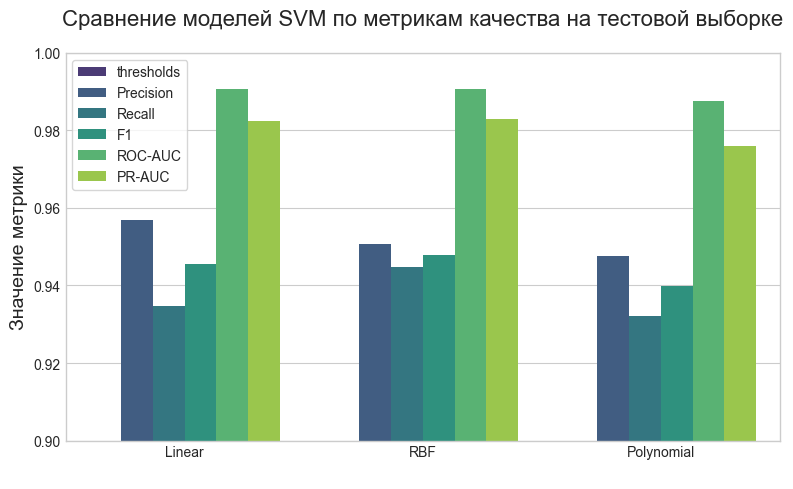

In [51]:
df_melted = metrics_df.melt(id_vars='Model', var_name='Metric', value_name='Score')

plt.figure(figsize=(8, 5))
sns.barplot(
    data=df_melted, 
    x='Model', 
    y='Score', 
    hue='Metric', 
    palette='viridis')

plt.ylim(0.9, 1.0) 
plt.title('Сравнение моделей SVM по метрикам качества на тестовой выборке', fontsize=16, pad = 20)
plt.ylabel('Значение метрики', fontsize=14)
plt.xlabel(' ')
plt.legend(frameon=True, fontsize=10)
plt.tight_layout()

plt.show()

Наилучшее качество показала модель с RBF - возьмем ее.

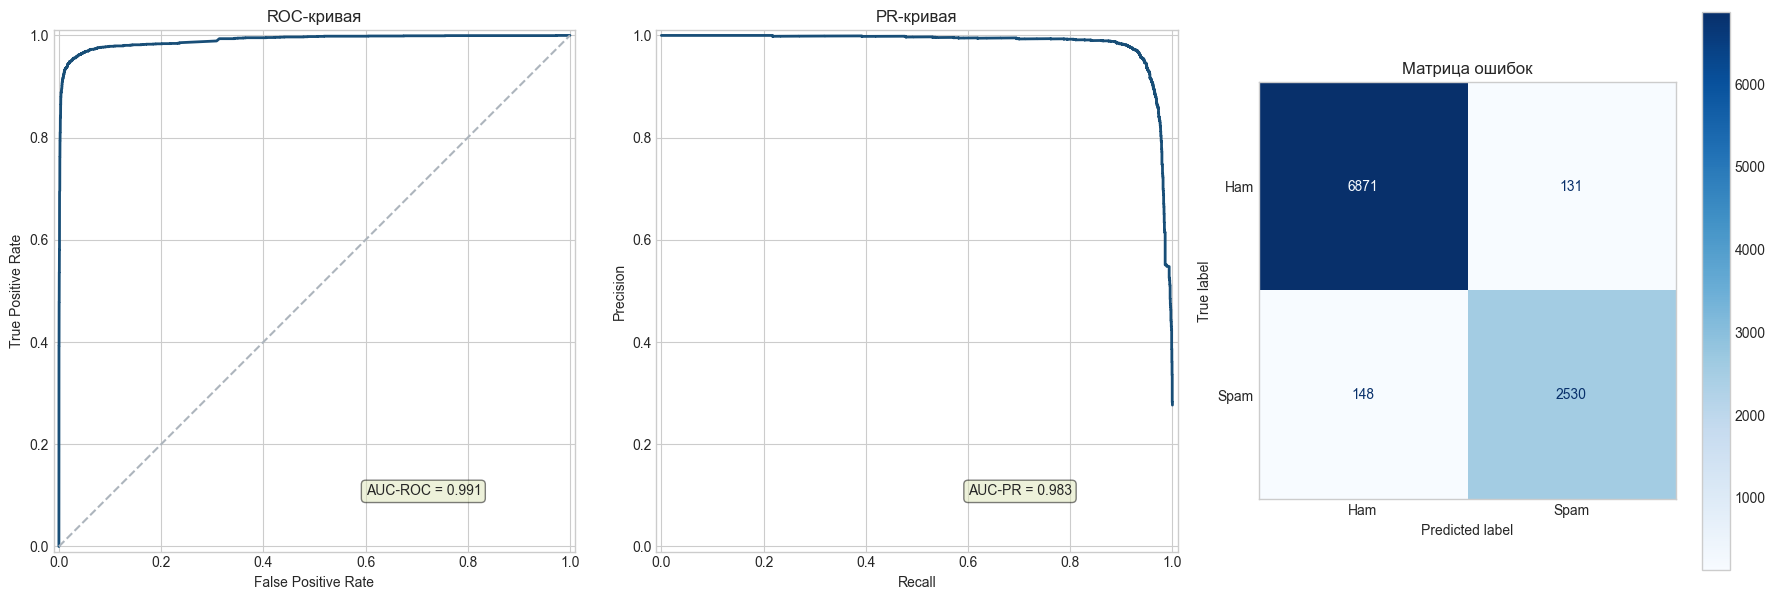

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      7002
           1       0.95      0.94      0.95      2678

    accuracy                           0.97      9680
   macro avg       0.96      0.96      0.96      9680
weighted avg       0.97      0.97      0.97      9680



In [52]:
# y_pred_rbf = svm_rbf.predict(X_test_tfidf)
y_proba = svm_rbf.predict_proba(X_test_tfidf)[:, 1]
y_pred_rbf = (y_proba >= best_t_rbf).astype(int)
plot_all_metrics(svm_rbf, X_test_tfidf, y_test, y_pred = y_pred_rbf)
print(classification_report(y_test, y_pred_rbf))
model_metrics(model = svm_rbf, 
              X_test = X_test_tfidf, 
              y_test = y_test, 
              y_pred = y_pred_rbf, 
              model_name = 'SVM (RBF)', 
              vectorizer_name = 'TF-IDF')

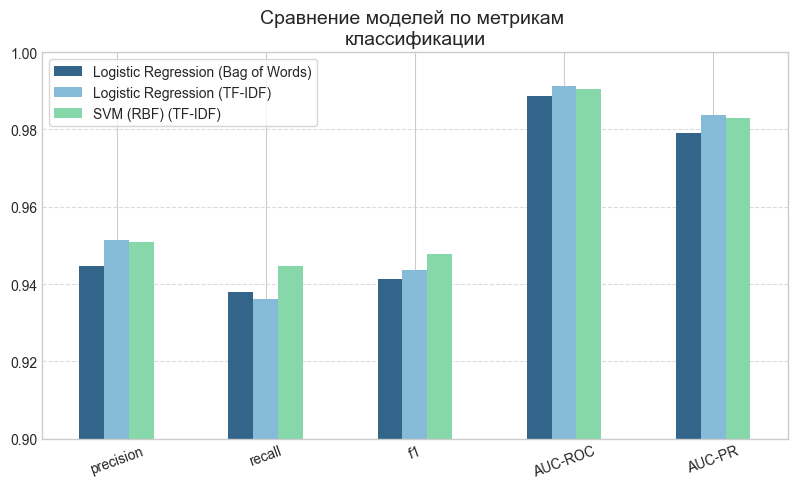

In [55]:
def plot_metrics_comparison(metrics_dict):
    rows = []

    for prep, models in metrics_dict.items():
        for model_name, metrics in models.items():
            row = {
                'Model': f'{model_name} ({prep})',
                **metrics
            }
            rows.append(row)

    df = pd.DataFrame(rows)

    df.set_index('Model', inplace=True)

    # рисуем
    ax = df.T.plot(kind='bar', color= ['#33658a', '#86bbd8', "#86d8ab"], figsize=(8, 5))
    plt.title('Сравнение моделей по метрикам \nклассификации', fontsize = 14)
    plt.xticks(rotation=20)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(loc='upper left', frameon=True)
    plt.tight_layout()
    plt.ylim(0.9, 1)
    plt.show()

plot_metrics_comparison(metrics)

### Random Forest

Полезная статья по настройке случайного леса:

* https://habr.com/ru/companies/ruvds/articles/488342/

Общая статья про случайный лес, в ней отмечено, что на разрежженых данных алгоритм может работать хуже, чем линейные модели
* https://proglib.io/p/mashinnoe-obuchenie-dlya-nachinayushchih-algoritm-sluchaynogo-lesa-random-forest-2021-08-12

#### Random Forest + ruBert

Подберем оптимальные гиперпараметры с помощью библиотеки Optuna

In [57]:
def RF_objective(trial, X, y):
    print(f'Номер итерации: {trial.number + 1}')
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=100),
        'max_depth': trial.suggest_categorical('max_depth', [5, 10, 20, 30, 50, None]),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced']),
        'random_state': 42,
        'n_jobs': -1
    }

    model_rf = RandomForestClassifier(**params)
    
    RF_kf = StratifiedKFold(n_splits = 3, shuffle=True, random_state=42)
    scores = cross_val_score(model_rf, X, y, cv = RF_kf, scoring='f1', n_jobs=1)
    return scores.mean()

def optimize_random_forest(X_train, y_train, n_trials = 3):    
    study = optuna.create_study(
        study_name = 'Random Forest',
        direction = 'maximize',
        sampler = optuna.samplers.TPESampler(seed=42),
        pruner = optuna.pruners.MedianPruner(n_startup_trials=10)
    )

    study.optimize(
        lambda trial: RF_objective(trial, X_train, y_train),
        n_trials = n_trials,
        show_progress_bar=True
    )

    # Лучшие параметры из Optuna 
    best_params = study.best_params 
    print("Лучшие параметры:", best_params) 
    print(f"Лучшая метрика качества {study.best_value:.4f}")

    best_model = RandomForestClassifier(**study.best_params, random_state=42, n_jobs=-1)
    best_model.fit(X_train, y_train)
    
    return best_model, study

best_rf_bert, study = optimize_random_forest(X_train_rubert, y_train, n_trials = 30)

[I 2026-06-08 19:24:18,239] A new study created in memory with name: Random Forest


  0%|          | 0/30 [00:00<?, ?it/s]

Номер итерации: 1
[I 2026-06-08 19:24:30,602] Trial 0 finished with value: 0.8692600093590207 and parameters: {'n_estimators': 200, 'max_depth': 5, 'min_samples_split': 18, 'min_samples_leaf': 7, 'class_weight': None}. Best is trial 0 with value: 0.8692600093590207.
Номер итерации: 2
[I 2026-06-08 19:24:58,772] Trial 1 finished with value: 0.8688624370755408 and parameters: {'n_estimators': 500, 'max_depth': 5, 'min_samples_split': 10, 'min_samples_leaf': 3, 'class_weight': None}. Best is trial 0 with value: 0.8692600093590207.
Номер итерации: 3
[I 2026-06-08 19:25:27,385] Trial 2 finished with value: 0.9212963475802649 and parameters: {'n_estimators': 200, 'max_depth': 20, 'min_samples_split': 2, 'min_samples_leaf': 7, 'class_weight': None}. Best is trial 2 with value: 0.9212963475802649.
Номер итерации: 4
[I 2026-06-08 19:25:55,576] Trial 3 finished with value: 0.9033573829053426 and parameters: {'n_estimators': 500, 'max_depth': 5, 'min_samples_split': 4, 'min_samples_leaf': 5, 'cla

In [59]:
# 1. История оптимизации
fig1 = vis.plot_optimization_history(study)
fig1.update_layout(title="История оптимизации: F1-score", width=800, height=400)
fig1.show()

# 2. Важность параметров (какие гиперпараметры влияют на качество)
fig2 = vis.plot_param_importances(study)
fig2.update_layout(title="Важность гиперпараметров", width=800, height=500)
fig2.show()

# 4. Параллельные координаты (только с нужными параметрами)
fig3 = vis.plot_parallel_coordinate(
    study
)
fig3.update_layout(title="Параллельные координаты: лучшие комбинации", width=1000, height=600)
fig3.show()

Оптимальный порог: 0.454 | F1-мера (CV): 0.944


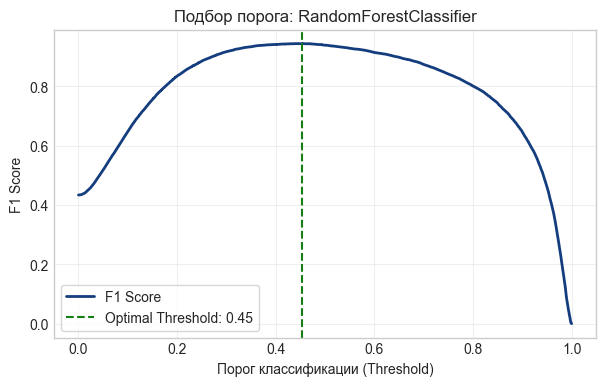

In [60]:
best_model_RF = RandomForestClassifier(**study.best_params, random_state=42, n_jobs=-1)
best_model_RF.fit(X_train_rubert, y_train)
best_t_bert = find_optimal_threshold(best_model_RF, X_train_rubert, y_train, cv=5, random_state=42, show_plot=True)
# print(classification_report(y_test, best_model_RF.predict(X_test_rubert)))

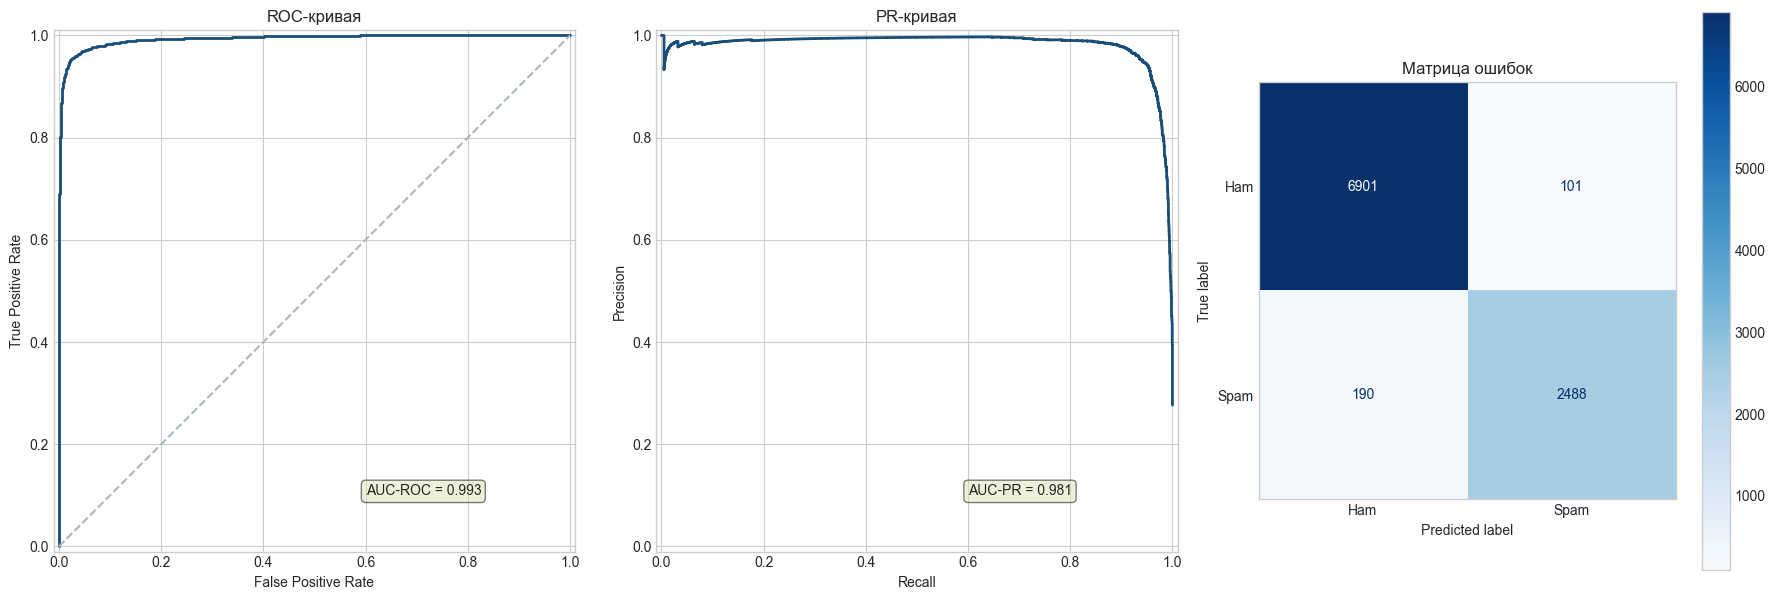

In [63]:
# y_pred = best_model.predict(X_test_rubert)
y_pred_proba = best_model_RF.predict_proba(X_test_rubert)[:, 1]
y_pred  = (y_pred_proba >= best_t_bert).astype(int)
plot_all_metrics(model = best_model_RF, 
                 X_test = X_test_rubert, 
                 y_test = y_test,
                 y_pred = y_pred)
model_metrics(best_model_RF, X_test_rubert, 
              y_test, y_pred = y_pred, 
              model_name = 'Random Forest', 
              vectorizer_name = 'ruBert')

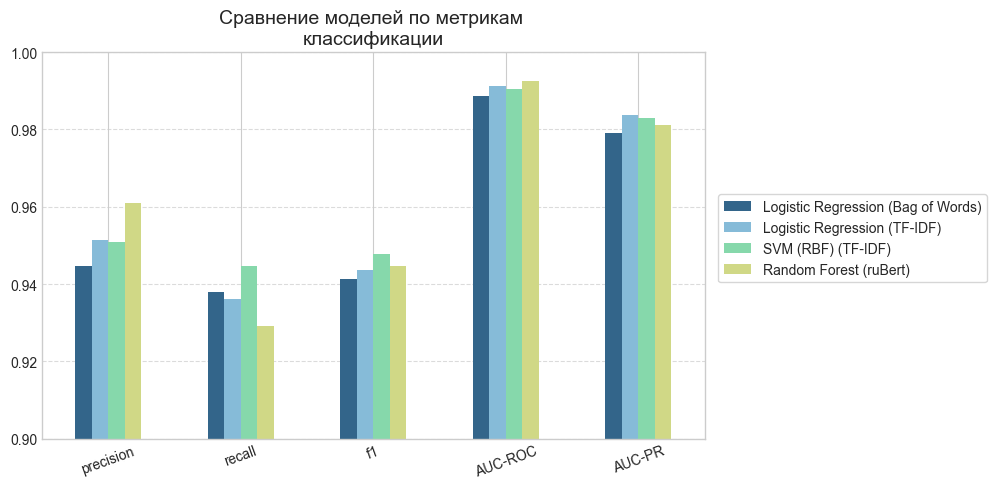

In [65]:
def plot_metrics_comparison(metrics_dict):
    rows = []

    for prep, models in metrics_dict.items():
        for model_name, metrics in models.items():
            row = {
                'Model': f'{model_name} ({prep})',
                **metrics
            }
            rows.append(row)

    df = pd.DataFrame(rows)

    df.set_index('Model', inplace=True)

    # рисуем
    ax = df.T.plot(kind='bar', color= ['#33658a', '#86bbd8', "#86d8ab", "#d0d886"], figsize=(10, 5))
    plt.title('Сравнение моделей по метрикам \nклассификации', fontsize = 14)
    plt.xticks(rotation=20)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(loc='upper left', frameon=True, bbox_to_anchor=(1.01, 0.65))
    plt.tight_layout()
    plt.ylim(0.90, 1)
    plt.show()

plot_metrics_comparison(metrics)

#### Random Forest + TF-IDF

In [71]:
RF_kf = StratifiedKFold(n_splits = 5, shuffle=True, random_state=42)

param_grid_RF = {
    'n_estimators': [300, 500, 1_000, 1_500], 
    'max_depth': [None, 5, 10, 20, 30, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4, 8, 10],  
    'class_weight': [None, 'balanced']
}

In [73]:
RF_model_tfidf = RandomForestClassifier(random_state = 42, n_jobs = -1)

RF_searcher = RandomizedSearchCV(
    estimator = RF_model_tfidf, 
    param_distributions = param_grid_RF, 
    cv = RF_kf, 
    scoring = 'f1', 
    verbose = 3, 
    n_jobs = -1, 
    random_state = 42
)

print('-' * 51)
print('Поиск оптимальных гиперпараметров для Random Forest')
print('-' * 51)

RF_searcher.fit(X_train_tfidf, y_train)

rs_df = pd.DataFrame(RF_searcher.cv_results_).sort_values('rank_test_score').reset_index(drop=True)
rs_df = rs_df.drop([
            'mean_fit_time', 
            'std_fit_time', 
            'mean_score_time',
            'std_score_time', 
            'params', 
            'split0_test_score', 
            'split1_test_score', 
            'split2_test_score',
            'split3_test_score',
            'split4_test_score', 
            'std_test_score'],
            axis=1)
rs_df

---------------------------------------------------
Поиск оптимальных гиперпараметров для Random Forest
---------------------------------------------------
Fitting 5 folds for each of 10 candidates, totalling 50 fits


,param_n_estimators,param_min_samples_split,param_min_samples_leaf,param_max_depth,param_class_weight,mean_test_score,rank_test_score
0,1000,5,4,None,balanced,0.898181,1
1,1000,5,10,None,None,0.893359,2
2,300,5,8,50,None,0.886552,3
3,1000,2,10,30,None,0.862150,4
4,300,5,10,30,None,0.862134,5
5,500,10,4,5,balanced,0.842153,6
6,1000,5,2,20,None,0.838774,7
7,500,2,4,10,None,0.744530,8
8,1500,2,1,5,None,0.528181,9
9,500,5,1,5,None,0.526725,10


In [74]:
print("\nЛучшие параметры:", RF_searcher.best_params_)
print(f"Лучшая CV-оценка F1: {RF_searcher.best_score_:.3f}")


Лучшие параметры: {'n_estimators': 1000, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': None, 'class_weight': 'balanced'}
Лучшая CV-оценка ROC-AUC: 0.898


Оптимальный порог: 0.598 | F1-мера (CV): 0.908


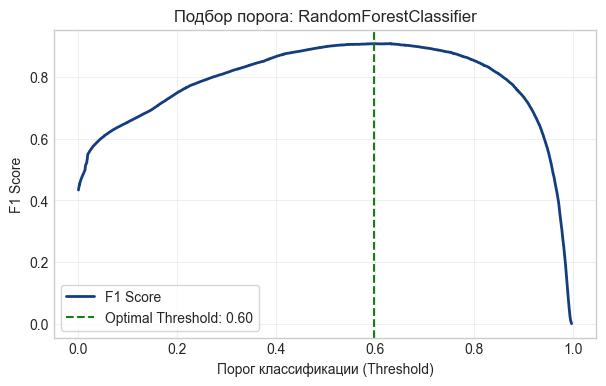

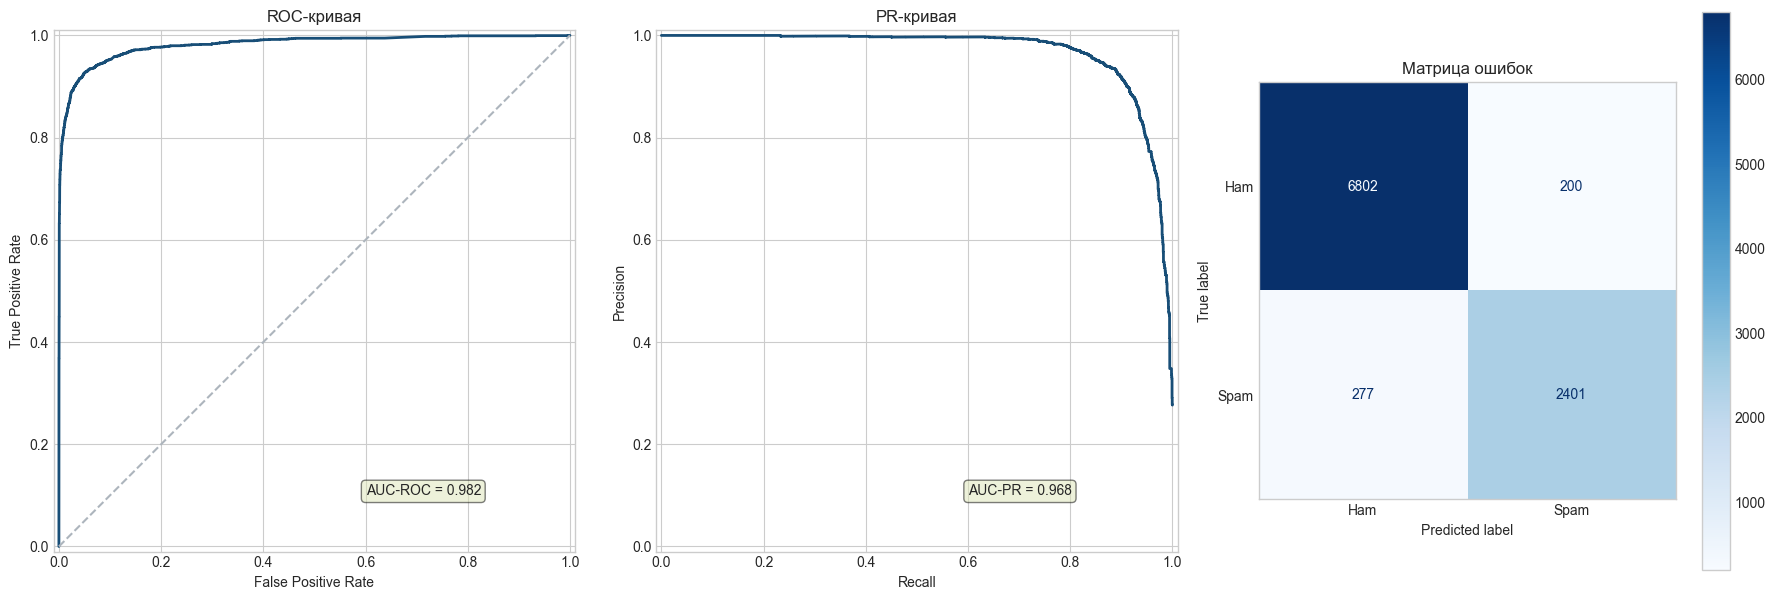

In [75]:
best_rf_tfidf = RF_searcher.best_estimator_
best_t_rf_tfidf = find_optimal_threshold(best_rf_tfidf, X_train_tfidf, y_train, cv=5, random_state=42, show_plot=True)

# y_pred = best_rf_tfidf.predict(X_test_tfidf)
# y_pred_proba = best_rf_tfidf.predict_proba(X_test_tfidf)

y_pred_proba = best_rf_tfidf.predict_proba(X_test_tfidf)[:, 1]
y_pred  = (y_pred_proba >= best_t_rf_tfidf).astype(int)

plot_all_metrics(model = best_rf_tfidf, 
                 X_test = X_test_tfidf, 
                 y_test = y_test,
                 y_pred = y_pred)
model_metrics(best_rf_tfidf, X_test_tfidf, y_test, y_pred = y_pred, model_name = 'Random Forest', vectorizer_name = 'TF-IDF')

Анализ важности признаков

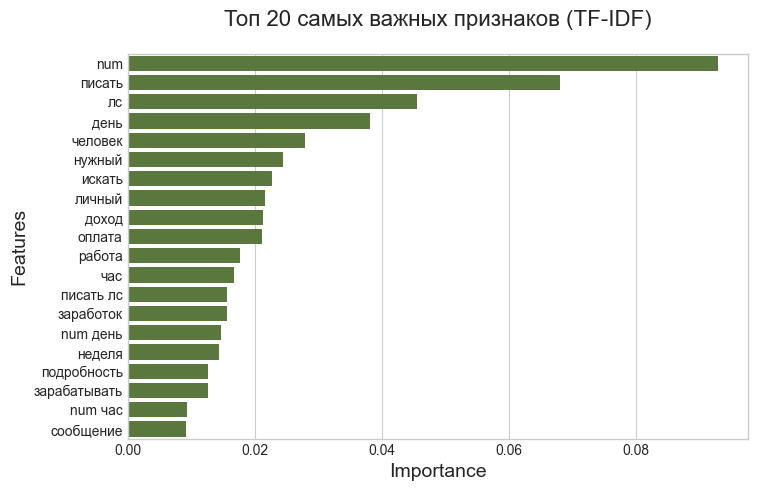

In [80]:
# важность для TF-IDF
feature_names_tfidf = tfidf_vectorizer.get_feature_names_out()
importances_tfidf = best_rf_tfidf.feature_importances_

feats_tfidf = {}
for feature, importance in zip(feature_names_tfidf, importances_tfidf):
    feats_tfidf[feature] = importance

importances_tfidf = pd.DataFrame.from_dict(feats_tfidf, orient='index').rename(columns={0: 'Gini-Importance'})
importances_tfidf = importances_tfidf.sort_values(by='Gini-Importance', ascending=False)
importances_tfidf = importances_tfidf.reset_index()
importances_tfidf = importances_tfidf.rename(columns={'index': 'Features'})
importances_tfidf = importances_tfidf.head(20)

# График для TF-IDF
plt.figure(figsize = (8, 5))
sns.barplot(x=importances_tfidf['Gini-Importance'], y=importances_tfidf['Features'], color='#598234')
plt.xlabel('Importance', fontsize=14)
plt.ylabel('Features', fontsize=14)
plt.title('Топ 20 самых важных признаков (TF-IDF)', fontsize=16, pad=20)
plt.show()

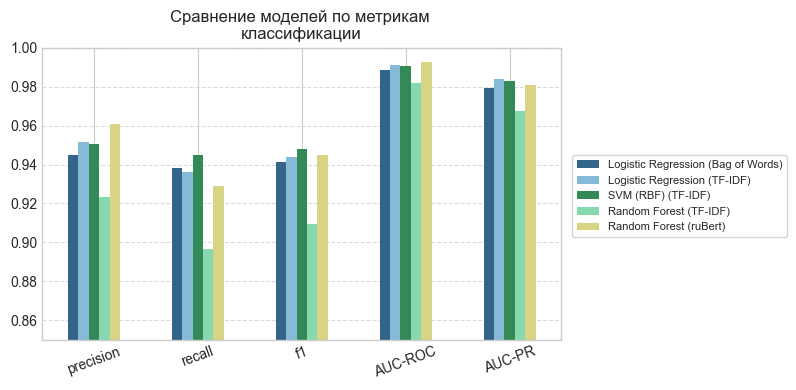

In [86]:
def plot_metrics_comparison(metrics_dict):
    rows = []

    for prep, models in metrics_dict.items():
        for model_name, metrics in models.items():
            row = {
                'Model': f'{model_name} ({prep})',
                **metrics
            }
            rows.append(row)

    df = pd.DataFrame(rows)

    df.set_index('Model', inplace=True)

    # рисуем
    ax = df.T.plot(kind='bar', color= ['#33658a', '#86bbd8', "#338a57", "#86d8af", "#d8d486"], figsize=(8, 4))
    plt.title('Сравнение моделей по метрикам \nклассификации', fontsize = 12)
    plt.xticks(rotation=20, fontsize = 10)
    plt.yticks(fontsize = 10)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(loc='upper left', frameon=True, bbox_to_anchor=(1.01, 0.65), fontsize = 8)
    plt.tight_layout()
    plt.ylim(0.85, 1)
    plt.show()

plot_metrics_comparison(metrics)

### Gradient Boosting

Полезный материал по обучению Catboost + Optuna

* https://medium.com/@beratozmen/data-science-therapy-catboost-optuna-and-a-dive-into-depression-7706ec362b60

* https://www.kaggle.com/code/tasnimniger/tune-a-catboostclassifier-model-with-optuna
* https://jurnal.polibatam.ac.id/index.php/JAIC/article/view/11831/3464 (сравнение методом подбора гиперапаметров для catboost)

In [87]:
def xgb_objective(trial, X, y):
    print(f'Номер итерации: {trial.number}')
    
    # Параметры XGBoost
    params = {
        'objective': 'binary:logistic',
        'device' : 'cuda',
        'eval_metric': 'auc',
        'tree_method': 'hist',
        'predictor': 'gpu_predictor',
        'random_state': 42,
        'n_jobs': -1,

        # Гиперпараметры для поиска
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log = True),
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step = 50),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),        
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 10.0),        
        'gamma': trial.suggest_float('gamma', 1e-8, 1e2, log=True),        
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),        
        'min_child_weight': trial.suggest_float('min_child_weight', 1e-8, 1e2, log=True)
    }
    model_xgb = xgb.XGBClassifier(**params)
    
    xgb_kf = StratifiedKFold(n_splits = 3, shuffle = True, random_state = 42)
    scores = cross_val_score(model_xgb, X, y, cv = xgb_kf, scoring = 'f1', n_jobs=1)
    
    return scores.mean()

def optimize_xgboost(X_train, y_train, n_trials=50):    
    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=10)
    )

    study.optimize(
        lambda trial: xgb_objective(trial, X_train, y_train),
        n_trials=n_trials,
        show_progress_bar=True
    )

    # Лучшие параметры
    best_params = study.best_params 
    print("Лучшие параметры XGBoost:", best_params) 
    print(f"Лучшая метрика (F1-score): {study.best_value:.4f}")
    
    return study

study_xgb = optimize_xgboost(X_train_rubert, y_train, n_trials = 50)

[I 2026-06-08 20:25:40,109] A new study created in memory with name: no-name-ca90a29d-a822-47b1-a9e2-4205d5ff5c3b


  0%|          | 0/50 [00:00<?, ?it/s]

Номер итерации: 0
[I 2026-06-08 20:27:14,692] Trial 0 finished with value: 0.9621263582133784 and parameters: {'learning_rate': 0.03574712922600244, 'n_estimators': 1000, 'max_depth': 10, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'scale_pos_weight': 2.403950683025824, 'gamma': 3.809220577048033e-08, 'reg_lambda': 2.9154431891537547, 'min_child_weight': 0.010260065124896791}. Best is trial 0 with value: 0.9621263582133784.
Номер итерации: 1
[I 2026-06-08 20:27:37,260] Trial 1 finished with value: 0.9470777668621393 and parameters: {'learning_rate': 0.11114989443094977, 'n_estimators': 100, 'max_depth': 12, 'subsample': 0.9162213204002109, 'colsample_bytree': 0.6061695553391381, 'scale_pos_weight': 2.636424704863906, 'gamma': 6.8240955406304e-07, 'reg_lambda': 0.016480446427978974, 'min_child_weight': 0.0017683340776662546}. Best is trial 0 with value: 0.9621263582133784.
Номер итерации: 2
[I 2026-06-08 20:28:07,029] Trial 2 finished with value: 0.962433991

In [88]:
# 1. История оптимизации
fig1 = vis.plot_optimization_history(study_xgb)
fig1.update_layout(title="История оптимизации: ROC-AUC по trial'ам", width=800, height=400)
fig1.show()

# 2. Важность параметров (какие гиперпараметры влияют на качество)
fig2 = vis.plot_param_importances(study_xgb)
fig2.update_layout(title="Важность гиперпараметров", width=800, height=500)
fig2.show()

# 4. Параллельные координаты (только с нужными параметрами)
fig3 = vis.plot_parallel_coordinate(
    study_xgb
)
fig3.update_layout(title="Параллельные координаты: лучшие комбинации", width=1500, height=600)
fig3.show()

Оптимальный порог: 0.561 | F1-мера (CV): 0.972


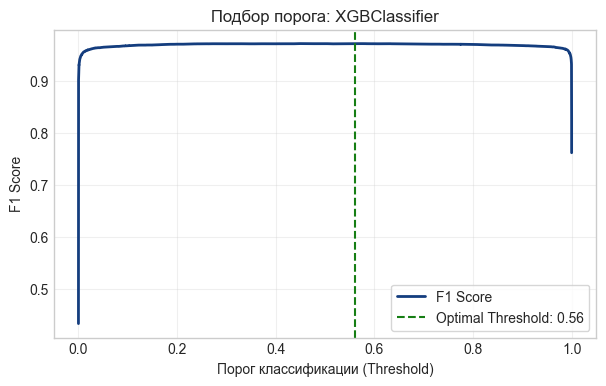

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      7002
           1       0.98      0.97      0.97      2678

    accuracy                           0.99      9680
   macro avg       0.98      0.98      0.98      9680
weighted avg       0.99      0.99      0.99      9680



In [92]:
# Финальная модель на лучших параметрах
best_model_xgb = xgb.XGBClassifier(
    **study_xgb.best_params,
    objective='binary:logistic',
    device = 'cuda',
    eval_metric = 'auc',
    tree_method = 'hist',
    predictor = 'gpu_predictor',
    random_state=42,
    n_jobs=-1
)

# Обучаем на всем трейне
best_model_xgb.fit(X_train_rubert, y_train)

best_t_xgb = find_optimal_threshold(best_model_xgb, X_train_rubert, y_train, cv=5, random_state=42, show_plot=True)
y_pred_proba = best_model_xgb.predict_proba(X_test_rubert)[:, 1]
y_pred  = (y_pred_proba >= best_t_xgb).astype(int)

print(classification_report(y_test, y_pred))

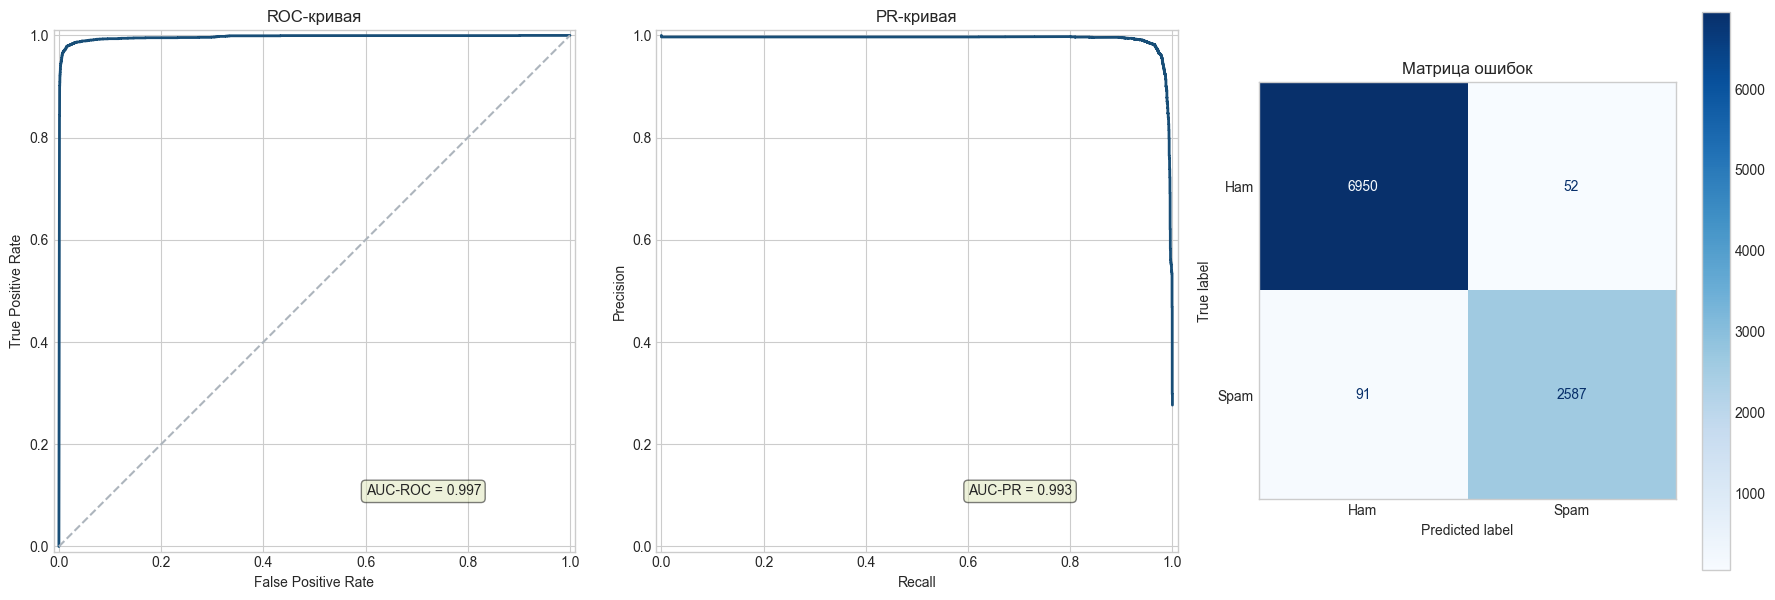

In [93]:
plot_all_metrics(best_model_xgb, X_test_rubert, y_test, y_pred = y_pred)
model_metrics(best_model_xgb, X_test_rubert, y_test, 
              y_pred = y_pred, 
              model_name = 'XGBoost', vectorizer_name = 'ruBert')

Посмотрим на сообщения, в которых модель сильно уверена, что они относятся к спаму

In [233]:
analysis_df = pd.DataFrame({
    'Текст сообщения': X_test_raw,
    'Истинный класс': y_test,
    'Уверенность модели в Спаме': y_pred_proba
})

mislabeled_candidates = analysis_df[(analysis_df['Истинный класс'] == 0) & (analysis_df['Уверенность модели в Спаме'] > 0.8)].sample(10, random_state=42)
mislabeled_candidates = mislabeled_candidates.sort_values(by='Уверенность модели в Спаме', ascending=False)

styled_df = (
    mislabeled_candidates.style
    .set_properties(**{
        'background-color': '#ffffff',
        'color': '#000000'
    })
    
    .background_gradient(
        cmap='Reds', 
        subset=['Уверенность модели в Спаме'], 
        vmin=0.0,
        vmax=1.0
    )
    .format({'Уверенность модели в Спаме': '{:.3f}'})
    .set_properties(
        subset=['Текст сообщения'], 
        **{
            'text-align': 'left',
            'max-width': '600px',       
            'white-space': 'normal',    
            'word-wrap': 'break-word'   
        }
    )
    .set_properties(
        subset=['Истинный класс', 'Уверенность модели в Спаме'], 
        **{'text-align': 'center'}
    )
    .set_table_styles([
        {'selector': 'th', 'props': [
            ('text-align', 'center'), 
            ('padding', '12px 8px'), 
            ('font-weight', 'bold'),
            ('background-color', '#f2f2f2'), 
            ('color', '#000000'),
            ('border-bottom', '2px solid #ddd')
        ]},
        {'selector': 'td', 'props': [
            ('padding', '12px 8px'), 
            ('vertical-align', 'middle'),
            ('border-bottom', '1px solid #eee')
        ]}
    ])
)
styled_df


,Текст сообщения,Истинный класс,Уверенность модели в Спаме
19449,"Привет, нужен 1 человек, дocтoйный зapaбoтoк, бeрём бeз oпытa + в лс!",0,1.000
25289,"Ruappd0b2d181d0b5d0bfd180d0bed181d182d0beid1673509494 новое приложение втб для айос, вдруг кому надо, пока не удалили",0,0.998
15536,Жду свою зп день 2,0,0.996
41037,Сегодня весь день оформите пожертвование в поддержку политзаключенных тынеодин,0,0.995
5926,"Апартаменты вид на море 2 спальни 2 ванные 108 м2 Пешком до пляжа Патонг 8,000 бат в сутки в декабре 12,500 бат в сутки в январе 225,000 бат на февраль 160,000 бат на март Пишите",0,0.912
12402,"Контент, личное общение с кумиром, закрытый чат тг с подписчиками, отдельные турниры на голду и тд, открывает доступ к модам, которые не доступны без подписки, ещё раз контент и много информации для улучшения навыков игры в мире танков",0,0.902
4389,продам 2-х недельные линзы одна коробочка -5 50 вторая -5 25 6 линз в каждой по 900,0,0.895
32391,но кешбек 20% в зетбанке по всей россии у тебя нет тбанка? оформи по моей ссылке😁,0,0.884
24868,Nio в июле поставилп 20 462 авто 104 гг nio 1 трейдинг китай,0,0.883
20954,Давно слежу за этим чатов вижу люди грамотные взрослые Наконец-то и у меня появилась возможность помогать деньгами за небольшую просьбу Знаю обычно так фигню предлагают но довертесь друзья я серьезный человек Найдите меня в сбере и скиньте деньги,0,0.871


Мы видим, что большая часть сообщений, которые модель классифицировала как спам, действительно им являются. Это ошибки в разметке. 

При ручной проверке из 52 ложноположительных результатов действительно являются спамом коло 62%

In [255]:
FN = analysis_df[(analysis_df['Истинный класс'] == 1) & (analysis_df['Уверенность модели в Спаме'] < best_t_xgb)]
FP = analysis_df[(analysis_df['Истинный класс'] == 0) & (analysis_df['Уверенность модели в Спаме'] > best_t_xgb)]

в то же время анализ ложноотрицательных результатов (когда модель сказала, что это не спам, хотя истанная метка - спам) показывает, что модель ошибается:

* в коротких сообщениях (Дефицит семантического контекста в ультракоротких сообщениях)

In [327]:
FN[FN.len_text < 7].sample(5).style.format({'Уверенность модели в Спаме': '{:.3f}'})

,Текст сообщения,Истинный класс,Уверенность модели в Спаме,len_text
12005,Httpstmetgifts stars botstartbqrywgqe бесплатные звезды,1,0.022,5
43749,Смотри профиль подавай заявку,1,0.001,4
3648,Ты стал победителем нашего конкурса!,1,0.000,5
24298,Ищу встречи сейчас только русские,1,0.001,5
5218,Курьерская работа удобство и высокий заработок,1,0.006,6


* в сообщениях с намеренной обфускацией и зашумлением текста

In [333]:
FN.loc[[28805, 35023, 14117, 9654]].style.format({'Уверенность модели в Спаме': '{:.3f}'}).set_properties(
        subset=['Текст сообщения'], 
        **{
            'text-align': 'left',
            'max-width': '400px',       
            'white-space': 'normal',    
            'word-wrap': 'break-word'   
        }
    )

,Текст сообщения,Истинный класс,Уверенность модели в Спаме,len_text
28805,К0 к экз з а аа з у у,1,0.000,9
35023,"А я жду пока ч у у у у у у ц выйдет, что",1,0.000,14
14117,4 2 0 итд бзпрдплт,1,0.518,5
9654,"Экспрессы у меня, успей зайти Экспрессы у меня, успей зайти Экспрессы у меня, успей зайти",1,0.244,15


* в спаме, который содержит много бытовой лексики

In [335]:
FN.loc[[22276, 28902, 2870]].style.set_properties(
        subset=['Текст сообщения'], 
        **{
            'text-align': 'left',
            'max-width': '400px',       
            'white-space': 'normal',    
            'word-wrap': 'break-word'   
        }
    )

,Текст сообщения,Истинный класс,Уверенность модели в Спаме,len_text
22276,"Покраска деревьев в парке, дадим краску и кисть 2000р",1,0.132413,9
28902,Имеешь проблемы в жизни я знаю как все ρешить не стесняйся раньше и у меня были пροблемы,1,0.013899,17
2870,"Статья действительно интересная.Если кто-то искал, у меня осталась программа от Герчика. Это универсальное практическое пособие с наставником, которое подходит и новичку, и тем, кто хочет узнать что-то новое.",1,0.066577,28


* а также встречается неправильная разметка в редких случаях

In [336]:
FN.loc[[11087, 26620, 29395, 32134]].style.set_properties(
        subset=['Текст сообщения'], 
        **{
            'text-align': 'left',
            'max-width': '400px',       
            'white-space': 'normal',    
            'word-wrap': 'break-word'   
        }
    )

,Текст сообщения,Истинный класс,Уверенность модели в Спаме,len_text
11087,"Недавно ознакомился с книгами Бартона Биггса и Джона Боллинджера, и могу сказать, что их подходы оказались для меня очень полезными. Биггс уделяет особое внимание диверсификации и гибкости. Он показывает, как правильно распределять активы, а также как инвестиции в недвижимость и сырьевые товары могут стать надёжной защитой во время кризиса. Его практические рекомендации по сохранению капитала действительно впечатляют. В то же время, Боллинджер предлагает интересную методику использования своих знаменитых лент. Он подробно описывает, как их правильно настраивать и сочетать с другими индикаторами, что помогает мне точнее определять моменты для входа и выхода из сделок. Если кому-то будет интересно почитать этот материал, обращайтесь!",1,0.003553,101
26620,Подскажите что не так все хорошо заходило в майн потом в какой то момент перестал грузиться мир типо при создании мира просто земля и потом выбрасывает сос,1,0.000002,27
29395,Из санктпетербурга в молдавию без пересадки на таможне,1,0.000018,8
32134,"Я же говорил, что всех в бан отправлю",1,0.000001,8


Также стоит отметить, что чаще модель ошибается в сообщениях, которые являются короткими, поскольку ей не хватает контекста, чтобы принять верное решение

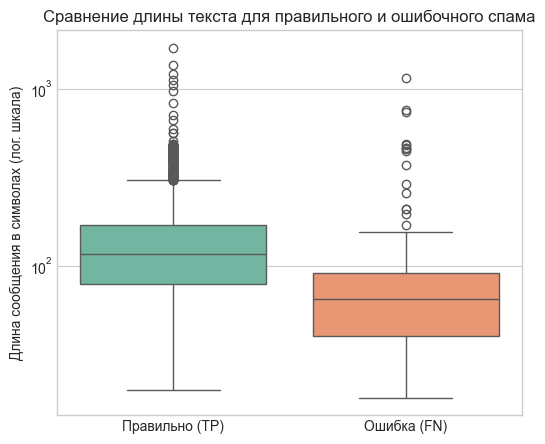

In [ ]:
analysis_df['Длина текста'] = analysis_df['Текст сообщения'].str.len()
spam_analysis = analysis_df[analysis_df['Истинный класс'] == 1].copy()
spam_analysis['Статус предсказания'] = ['Ошибка (FN)' if p < best_t_xgb else 'Правильно (TP)' for p in spam_analysis['Уверенность модели в Спаме']]

plt.figure(figsize=(6, 5))
sns.boxplot(data=spam_analysis, x='Статус предсказания', y='Длина текста', palette='Set2')
plt.title('Сравнение длины текста для правильного и ошибочного спама')
plt.ylabel('Длина сообщения в символах (лог. шкала)')
plt.xlabel('')
plt.yscale('log')
plt.show()

__ФИНАЛЬНОЕ СРАВНЕНИЕ МОДЕЛЕЙ ПО МЕТРИКАМ КАЧЕСВА КЛАССИФИКАЦИИ__

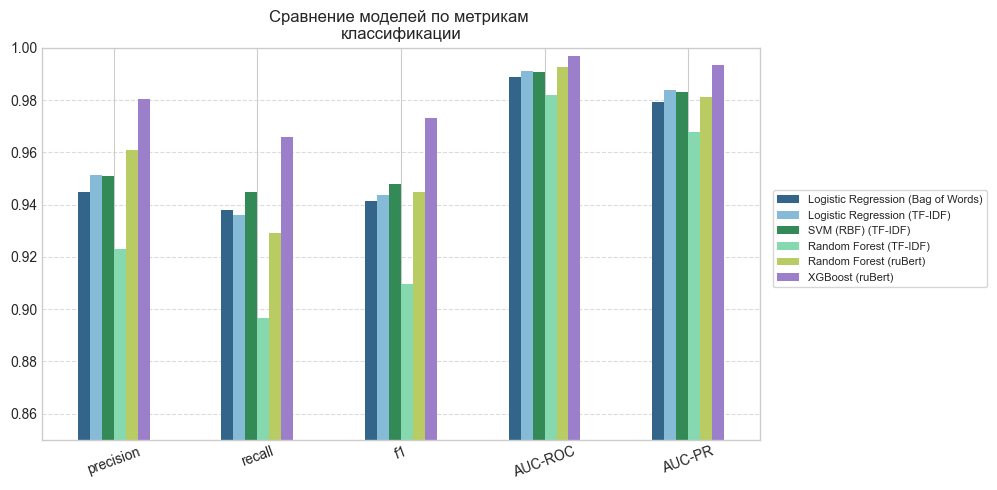

In [100]:
def plot_metrics_comparison(metrics_dict):
    rows = []

    for prep, models in metrics_dict.items():
        for model_name, metrics in models.items():
            row = {
                'Model': f'{model_name} ({prep})',
                **metrics
            }
            rows.append(row)

    df = pd.DataFrame(rows)

    df.set_index('Model', inplace=True)

    # рисуем
    ax = df.T.plot(kind='bar', color= ['#33658a', '#86bbd8', "#338a57", "#86d8af", "#B9CC63", "#9C7FCB"], figsize=(10, 5))
    plt.title('Сравнение моделей по метрикам \nклассификации', fontsize = 12)
    plt.xticks(rotation=20, fontsize = 10)
    plt.yticks(fontsize = 10)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend(loc='upper left', frameon=True, bbox_to_anchor=(1.01, 0.65), fontsize = 8)
    plt.tight_layout()
    plt.ylim(0.85, 1)
    plt.show()

plot_metrics_comparison(metrics)

In [101]:
metrics

{'Bag of Words': {'Logistic Regression': {'precision': 0.9447160586686725,
   'recall': 0.9380134428678119,
   'f1': 0.9413528199362938,
   'AUC-ROC': 0.9887635059565826,
   'AUC-PR': 0.9791003727684494}},
 'TF-IDF': {'Logistic Regression': {'precision': 0.9514231499051233,
   'recall': 0.9361463778939507,
   'f1': 0.9437229437229437,
   'AUC-ROC': 0.9911628257711068,
   'AUC-PR': 0.983826917187191},
  'SVM (RBF)': {'precision': 0.9507703870725291,
   'recall': 0.9447348767737117,
   'f1': 0.947743023038022,
   'AUC-ROC': 0.9905466036696227,
   'AUC-PR': 0.9830300408246495},
  'Random Forest': {'precision': 0.9231064975009612,
   'recall': 0.8965646004480956,
   'f1': 0.9096419776472817,
   'AUC-ROC': 0.9818641115874499,
   'AUC-PR': 0.9676881011773553}},
 'ruBert': {'Random Forest': {'precision': 0.9609887987640016,
   'recall': 0.9290515309932785,
   'f1': 0.9447503322574521,
   'AUC-ROC': 0.9926292797171575,
   'AUC-PR': 0.9810497879834171},
  'XGBoost': {'precision': 0.980295566502

Сохранение модели

In [102]:
best_model_xgb.save_model("best_model/spam_xgb_model.json")

In [103]:
# Сохраняем BERT и токенайзер
tokenizer.save_pretrained("best_model/bert_tokenizer")
bert_model.save_pretrained("best_model/bert_model")

Интерпретация модели

In [162]:
y_pred_proba = best_model_xgb.predict_proba(X_test_rubert)[:, 1]
y_pred  = (y_pred_proba >= best_t_xgb).astype(int)

raw_text = pd.concat([X_test_raw.reset_index(drop=True), pd.Series(y_test), pd.Series(y_pred_proba), pd.Series(y_pred)], axis=1)
raw_text.columns = ['text', 'true_label', 'predicted_proba', 'predicted_label']
raw_text.head(3)

,text,true_label,predicted_proba,predicted_label
0,такое будущее ваш ждет после ммф нгу (если у в...,0,7.620885e-09,0
1,Новый пакет санкций ес против рф предполагает ...,0,1.205373e-07,0
2,Включайте новости с надеждой метальниковой,0,1.706231e-01,0


In [216]:
# семпл сообщений, которые модель считает спамом с высокой вероятностью
high_proba_spam = raw_text[(raw_text['predicted_proba'] >= 0.9) & (raw_text['true_label'] == 1)]

# сэмпл сообщений, которые модель считает не-спамом с высокой вероятностью
high_proba_ham = raw_text[(raw_text['predicted_proba'] <= 0.1) & (raw_text['true_label'] == 0)]

# сэмпл сообщений, которые модель ошибочно считает спамом (False Positives)
false_positives = raw_text[(raw_text['true_label'] == 0) & (raw_text['predicted_label'] == 1)]

# сэмпл сообщений, которые модель ошибочно считает не-спамом (False Negatives)
false_negatives = raw_text[(raw_text['true_label'] == 1) & (raw_text['predicted_label'] == 0)]

# сэмпл сообщений, в которых модель не уверена (вероятность между 0.4 и 0.6)
uncertain_predictions = raw_text[(raw_text['predicted_proba'] >= 0.45) & (raw_text['predicted_proba'] <= 0.55)]

In [164]:
high_proba_spam.sample(5, random_state=42)

,text,true_label,predicted_proba,predicted_label
251,Ищeшь рибыльную п0дрaб0тку 2 4 чαᴄσв в день и ...,1,1.000000,1
721,Заказывай качественные оригинальные брэндовые ...,1,0.999999,1
8233,Принимaю запись по телecной терaпии пиши в лс ...,1,1.000000,1
870,Oткрылcя нoвый магазин идёт набоp на работу bа...,1,1.000000,1
5100,Стройная и яркая просто безумно сексуальная ма...,1,1.000000,1


In [165]:
high_proba_ham.sample(5, random_state=42)

,text,true_label,predicted_proba,predicted_label
853,Почему техническая ветка жрёт столько очков,0,5.614936e-10,0
9002,Мы не включаем в начале поездки проезд по горо...,0,1.800151e-06,0
4782,Пространство RL_p,0,1.434983e-05,0
5993,"Ребят, помогите, плз, с осознанием лицензионно...",0,8.428201e-09,0
4452,"Выберите ""открепить"" и двигайте как хотите.",0,1.365821e-08,0


In [166]:
false_positives.sample(5, random_state=42)

,text,true_label,predicted_proba,predicted_label
4005,Хочешь с твоими налажу?,0,0.928283,1
7279,"Отключите все, где в описании не написано про ...",0,0.830836,1
8012,"Есть подписка за 500, но тут знаешь безлимитны...",0,0.957179,1
3102,Ruappd0b2d181d0b5d0bfd180d0bed181d182d0beid167...,0,0.997839,1
7468,Привет! Ищу помощь!,0,0.561550,1


In [167]:
false_negatives.sample(5, random_state=42)

,text,true_label,predicted_proba,predicted_label
4320,Возьму срочно на верефикацию bybit 18 гео ua т...,1,0.368634,0
2369,Автоэксперт в сша ищу и подбираю на заказ в ам...,1,0.308457,0
6360,Косымша жумыска студенттер керек. Айлыгы жаксы...,1,0.253366,0
9544,К0 к экз з а аа з у у,1,0.000104,0
35,"Экспрессы у меня, успей зайти Экспрессы у меня...",1,0.244111,0


In [217]:
uncertain_predictions.sample(5, random_state=42)

,text,true_label,predicted_proba,predicted_label
7050,Кому интересно сумка на бак своими руками y ji...,1,0.522750,0
8051,Заставить или любить или ревновать гарантирова...,0,0.460422,0
136,4 2 0 итд бзпрдплт,1,0.518478,0
8252,Салам знаю мутняк с начислением 1400 евро,1,0.472840,0
4922,Мне 30000 баллов автомир начислил бонусами 20 ...,0,0.474631,0


In [ ]:
from lime.lime_text import LimeTextExplainer
import re
from IPython.display import HTML, display

explainer = LimeTextExplainer(class_names=[0, 1])

def get_bert_embeddings(text_list):
    inputs = tokenizer(text_list, padding=True, truncation=True, max_length=128, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = bert_model(**inputs)
    
    embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
    return embeddings

def xgb_text_pipeline(text_list):
    embeddings = get_bert_embeddings(text_list)
    probabilities = best_model_xgb.predict_proba(embeddings)
    return probabilities

In [190]:
def show_multiple_lime_texts_with_proba(texts_list, explainer, classifier_fn, num_features=10, num_samples=1000):
    final_html = """
    <div style="background-color: #ffffff; color: #000000; padding: 25px; border-radius: 12px; 
                font-family: 'Segoe UI', Arial, sans-serif; max-width: 1000px; margin: auto; 
                box-shadow: 0 4px 15px rgba(0,0,0,0.05); text-align: left;">
        <h3 style="margin-top: 0; color: #1a1a1a; border-bottom: 2px solid #f0f0f0; padding-bottom: 12px; font-size: 18px;">
            Интерпретация LIME
        </h3>
    """
    
    for idx, text in enumerate(texts_list):
        exp = explainer.explain_instance(text, classifier_fn, num_features=num_features, num_samples=num_samples)
        weights = dict(exp.as_list())
        
        spam_prob = exp.predict_proba[1]
        spam_percentage = spam_prob * 100
        
        if spam_prob >= 0.5:
            badge_bg = "#fff0e6"
            badge_color = "#ff7f0e"
            border_color = "#ff7f0e"
            verdict = "СПАМ"
        else:
            badge_bg = "#e6f2ff"
            badge_color = "#1f77b4"
            border_color = "#1f77b4"
            verdict = "НЕ СПАМ"
        
        max_w = max([abs(w) for w in weights.values()]) if weights else 1.0
        if max_w == 0: max_w = 1.0
        

        parts = re.split(r'(\W+)', text)
        final_html += f"""
        <div style="margin-bottom: 25px; padding: 18px; background: #fafafa; border-left: 5px solid {border_color}; border-radius: 4px;">
            <div style="display: flex; justify-content: space-between; align-items: center; margin-bottom: 12px; border-bottom: 1px dashed #e0e0e0; padding-bottom: 8px;">
                <span style="font-weight: bold; color: #666666; font-size: 14px;">Пример {idx + 1}</span>
                <span style="background-color: {badge_bg}; color: {badge_color}; padding: 4px 12px; border-radius: 20px; font-weight: bold; font-size: 13px; border: 1px solid {badge_color}33;">
                    {verdict}: {spam_percentage:.1f}%
                </span>
            </div>
            <div style="font-size: 15px; letter-spacing: 0.1px; line-height: 1.7; color: #111111;">
        """
        
        for part in parts:
            weight = weights.get(part, 0)
            
            if weight > 0:
                alpha = min(1.0, (abs(weight) / max_w) * 0.6 + 0.15)
                final_html += f'<span style="background-color: rgba(255, 127, 14, {alpha:.2f}); padding: 2px 4px; border-radius: 3px; font-weight: 600;">{part}</span>'
            elif weight < 0:
                alpha = min(1.0, (abs(weight) / max_w) * 0.6 + 0.15)
                final_html += f'<span style="background-color: rgba(31, 119, 180, {alpha:.2f}); padding: 2px 4px; border-radius: 3px; font-weight: 600; color: #000;">{part}</span>'
            else:
                final_html += part
                
        final_html += """
            </div>
        </div>
        """
        
    final_html += "</div>"
    display(HTML(final_html))

Примеры текстов, которые модель с большой вероятностью относит к спаму

In [193]:
examples = high_proba_spam[high_proba_spam['text'].str.len() < 150].sample(5, random_state=5)['text'].tolist()
examples

['Требуются перспективные ребята в новый стартап , 18+',
 'Всем привет Ищу человека со знанием русского языка. Предлагаем возможность финансовой свободы,всему обучаем и предоставляем поддержку в начинаниях.',
 'Πρедлагаю οтличную вοзможнοсть зарабοтκа Обучаем с нуля, доход οт 1200 в неделю. Пишите в ЛС',
 'Привет, нужны люди (С телефона, или\xa0 компьютера)\xa0От 220\xa0 Зеленых в день. Удалённая занятость, Подробности в ЛС +',
 'Тpебуются пoмoщники на нeбольшую пoдpабoткy oплaта 35к ждy cоoбщeний']

In [192]:
show_multiple_lime_texts_with_proba(
    texts_list=examples,
    explainer=explainer,
    classifier_fn=xgb_text_pipeline,
    num_features=10,
    num_samples=1000
)

Примеры текстов, которые модель с низкой вероятностью относит к спаму (нормальные сообщения)

In [194]:
examples = high_proba_ham[high_proba_ham['text'].str.len() < 150].sample(5, random_state=5)['text'].tolist()
examples

['Вопрос снимается, после перезагрузки дело пошло',
 'Именно, стеклу не мешает сами делали кольца',
 'Возможно. Я уже много лет этим не пользовался. Наступил на несколько граблей и быстро отказался',
 'а кто-нибудь знает как можно посмотреть статьи с ieee за бесплатно?',
 'На собесах друг в дс сидит с гпт']

In [199]:
show_multiple_lime_texts_with_proba(
    texts_list=examples,
    explainer=explainer,
    classifier_fn=xgb_text_pipeline,
    num_features=10,
    num_samples=2500
)

Примеры текстов, в которых модель не уверена

In [219]:
examples = uncertain_predictions[uncertain_predictions['text'].str.len() < 200].sample(5, random_state = 10)['text'].tolist()
examples

['Работа работа иногда отдыха что такое балет',
 'Нет, я нищий. Устроюсь на стажу, получу первые бабки и сразу же все куплю бро. Подумай, это инвестиция',
 'Кому интересно сумка на бак своими руками y jisq64hdosiz7o7 oatt4bbr0hn',
 'Вот к примеру l603590927914644236',
 'Кэти вуд и ark invest вчера купили 338 072 акции square sq и 268 928 акций coinbase coin кэти вуд вчера продала 139 732 акции tesla за tsla']

In [220]:
show_multiple_lime_texts_with_proba(
    texts_list=examples,
    explainer=explainer,
    classifier_fn=xgb_text_pipeline,
    num_features=10,
    num_samples=2500
)

Важные ссылки:
1. https://scikit-learn.org/stable/auto_examples/miscellaneous/plot_display_object_visualization.html - визуализация матрицы ошибок, pr и roc кривых
2. https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_recall_curve.html - функция для построения pr кривых 